# Análisis Topológico de la Ingesta de Ácido Fólico en Mujeres Chilenas
## Semanas 1 y 2 — Comprensión de Datos, EDA, Clustering Clásico y TDA Mapper

---

**Equipo 5** | Mariel Álvarez · Viviana · Ana · Álvaro · Jorge  
**Curso:** Uso de Geometría y Topología para la Ciencia de Datos  
**Fecha:** Mayo – Junio 2026  

---

### Referencia al Plan de Trabajo

Este notebook implementa las tareas de las **Semanas 1 y 2** del plan de trabajo del Equipo 5:

| Semana | Tareas cubiertas |
|--------|------------------|
| **Semana 1** | T1.1 Revisión de diccionarios y variables · T1.2 EDA · T1.3 Estrategia de aislamiento de covariables · T1.4 Diseño de pipeline |
| **Semana 2** | T2.1 Preprocesamiento para TDA · T2.2 Clustering clásico · T2.3 Mapper lente UMAP-AF · T2.4 Mapper lente salud neonatal · T2.5 Interpretación · T2.6 Homología persistente |

### Objetivo principal

> Caracterizar subpoblaciones de mujeres embarazadas con distintos patrones de ingesta de ácido fólico (AF) y resultados materno-infantiles, aislando el efecto de variables socioeconómicas y de salud materna.

### Estructura del notebook

```
0. Configuración e importaciones
── SEMANA 1 ──────────────────────────────────────────
1. Carga de datos y revisión de diccionarios    (T1.1)
2. Análisis Exploratorio de Datos (EDA)         (T1.2)
   2.1 Grupos de variables
   2.2 Distribuciones univariadas
   2.3 Análisis de valores faltantes
   2.4 Detección de valores atípicos
   2.5 Correlaciones
   2.6 Análisis bivariado AF – Desenlaces
3. Estrategia de aislamiento de covariables     (T1.3)
4. Diseño y resumen del pipeline TDA            (T1.4)
── SEMANA 2 ──────────────────────────────────────────
5. Preprocesamiento final para TDA              (T2.1)
6. Clustering clásico (K-Means + Ward)          (T2.2)
7. Mapper con lente UMAP sobre ingesta de AF    (T2.3)
8. Mapper con lente de salud neonatal           (T2.4)
9. Interpretación y comparación de Mappers      (T2.5)
10. Homología persistente                        (T2.6)
11. Resumen de hallazgos y próximos pasos
```


---
## 0. Configuración e Importaciones

Se importan todas las librerías necesarias para el análisis. Las librerías de TDA (`kmapper`, `umap-learn`, `ripser`, `persim`) corresponden al stack tecnológico definido en la Sección 6 del plan de trabajo.


para correrlo:

```pip install matplotlib numpy pandas scipy seaborn missingno scikit-learn kmapper umap-learn ripser persim openpyxl networkx```

In [1]:
%matplotlib inline
import matplotlib
# ── Librerías estándar ──────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# ── Visualización ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno

# ── Machine Learning / Clustering ────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── TDA ──────────────────────────────────────────────────────────────────
try:
    import kmapper as km
    from kmapper import Cover
    print('KeplerMapper:', km.__version__)
except ImportError:
    print('KeplerMapper no disponible — instalar: pip install kmapper')


try:
    from ripser import ripser
    from persim import plot_diagrams
    print('Ripser / Persim: OK')
except ImportError:
    print('Ripser/Persim no disponibles — instalar: pip install ripser persim')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# Estilo de figuras
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'sans-serif'
})
sns.set_style('whitegrid')
print('\nConfiguración completada.')


KeplerMapper: 2.1.0
Ripser / Persim: OK

Configuración completada.


In [2]:
# ── Rutas del proyecto ───────────────────────────────────────────────────
# Búsqueda robusta del directorio raíz del proyecto (compatible con Jupyter y nbconvert)
from pathlib import Path
import os

_cwd = Path(os.getcwd())
PROJECT_DIR = None
for _candidate in [_cwd, _cwd.parent, _cwd.parent.parent]:
    if (_candidate / 'data' / 'processed').exists():
        PROJECT_DIR = str(_candidate)
        break
if PROJECT_DIR is None:
    raise FileNotFoundError("No se encontró el directorio del proyecto. "
                            "Ejecuta el notebook desde tda_project/ o tda_project/notebooks/")

PROC_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
OUT_DIR  = os.path.join(PROJECT_DIR, 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

print(f'Directorio proyecto : {PROJECT_DIR}')
print(f'Datos procesados    : {PROC_DIR}')
print(f'Outputs             : {OUT_DIR}')


Directorio proyecto : /Users/alvarobolanos/Desktop/tda_project
Datos procesados    : /Users/alvarobolanos/Desktop/tda_project/data/processed
Outputs             : /Users/alvarobolanos/Desktop/tda_project/outputs


---
# SEMANA 1: Comprensión de Datos y Diseño del Análisis
> **Objetivo:** Establecer un entendimiento profundo de ambos datasets, identificar variables clave y acordar la estrategia metodológica completa.

Cubre las tareas T1.1 – T1.4 del plan de trabajo.


---
## 1. Carga de Datos y Revisión de Diccionarios de Variables `[T1.1]`

Se trabaja con dos datasets ya procesados y limpios:

- **Dataset 1** (`dataset1_ingesta_af_limpio.xlsx`): encuesta a 1,170 mujeres sobre ingesta de AF, hábitos alimenticios y resultados de salud materno-infantil.
- **Dataset 2** (`dataset2_encuesta_af_limpio.xlsx`): 850 registros con cuantificación detallada del aporte diario de AF (mg/día) por fuente — suplementos, pan y pasta — más indicadores de IMC y salud neonatal.

Los diccionarios de variables (`diccionario_dataset*.csv`) documentan cada columna con tipo analítico, descripción y estadísticas de completitud.


In [3]:
# ── Carga de datasets procesados ────────────────────────────────────────
df1 = pd.read_csv(os.path.join(PROC_DIR, 'dataset1_ingesta_af_limpio.csv'))
df2 = pd.read_csv('dataset2_limpio.csv')

print(f'Dataset 1: {df1.shape[0]:,} registros × {df1.shape[1]} variables')
print(f'Dataset 2: {df2.shape[0]:,} registros × {df2.shape[1]} variables')


Dataset 1: 1,170 registros × 68 variables
Dataset 2: 705 registros × 67 variables


In [4]:
# ── Identificación de grupos de variables (T1.1) ────────────────────────
# Estas listas guían todo el análisis posterior.

# --- Dataset 1 ---
VARS_SOCIO_D1 = ['edad', 'region_chile', 'neduc', 'paridad']

VARS_AF_SUPL_D1 = [
    'consumio_saf_binario', 'uf_af',
    'folacid_1_mg', 'folacid_5_mg', 'folifeminaf_5mg',
    'folisanin_1_mg', 'folisanin_5_mg', 'folvit_1', 'folvit_5',
    'heliofol_1', 'heliofol_5_mg', 'miliser_1_mg', 'miliser_5_mg',
    'fersitol_1', 'supradyn_prenatal', 'no_consumio'
]

VARS_AF_TIMING_D1 = [
    'antes_del_embarazo', '1_3_meses', '4_6_meses', '7_9_meses',
    'durante_todo_el_embarazo', 'durante_el_periodo_de_lactancia',
    'no_consumi_suplemento_en_ningun_periodo'
]

VARS_DIETA_D1 = [
    'carnes_rojas', 'carnes_blancas', 'lacteos', 'huevos',
    'cualquier_producto_de_origen_animal', 'no_deje_de_comer_ninguno',
    'marraqueta', 'hallulla', 'pan_molde_blanco', 'pan_molde_integral',
    'pan_pita', 'no_como_pan', 'n_panes'
]

VARS_OUTCOME_D1 = [
    'pnacer', 'edad_gestacion_ultimo_hijo', 'categoria_pnacer',
    'preeclamsia', 'diabetes_gestacional',
    'restriccion_del_crecimiento_intrauterino_rciu',
    'embarazo_multiple', 'sitgest', 'probnac'
]

# --- Dataset 2 ---

VARS_SOCIO_D2 = [
    'Edad madre', 'Nacionalidad', 'Agrupación nacionalidad',
    'Región', 'Educación', 'N° embarazo'
]

VARS_ANTROPOMETRIA_D2 = [
    'KG inicio mamá', 'KG fin mamá', 'Dif peso mamá',
    'Estatura mamá', 'IMC antes', 'IMC después', 'Dif IMC'
]

VARS_GESTACION_D2 = [
    'FN hijo', 'Período', 'Sexo hijo',
    'EG hijo (sem)', 'Condición mamá'
]

VARS_AF_SUPL_D2 = [
    '¿Consume suplementos y/o multivitamínico de AF en embarazo?',
    '¿Consume SAF?',
    "¿Consume SAF+OSAF?",
    'Código SAF',
    'mgAF/cáp SAF+OSAF',
    '¿Cuántos días de SAF?',
    '¿Cuántas cáp SAF?',
    'mgAF/día SAF',
    '¿Consumió MAF?',
    "¿Consumió MAF completo?",
    'Código MAF',
    'mgAF/cáp MAF',
    '¿Cuántos días de MAF?',
    '¿Cuántas cáp MAF?',
    'mgAF/día MAF 1°T',
    'Consumo OSAF 1° toma',
    'Consumo OSAF 2° toma',
    'Consumo OSAF completo',
    'Código OSAF',
    'mgAF/cáp OSAF',
    '¿Cuántos días de OSAF?',
    '¿Cuántas cáp OSAF?',
    "mgAF/día OSAF 1°T",
    'mgAF/día SAF+OSAF 2°T',
    'mgAF/día Suplementos y multivitamínico 1°T',
    'mg/día DFE suplementos y multivitamínico 1°T',
    'Días consumo MAF',
    'mgAF/día período MAF',
    'Días consumo suplementosAF',
    'mgAF/día total período SAF+OSAF',
    'TOTAL AF mg suplementos y multivitamínicos período ',
    'Código consumo SIN'
]

VARS_AF_TIMING_D2 = [
    'Período consumo SAF+OSAF',
    'Consumo OSAF 1° toma',
    'Consumo OSAF 2° toma',
    'Consumo OSAF completo'
]

VARS_DIETA_D2 = [
    'Código alimentos',
    '¿Consumió pan?',
    'Código pan',
    'mgAF/unidad pan',
    'Código pan/día consumido',
    'mg/d AF total pan',
    'mg/d DFE total pan',
    'Total mg/d AF  suple y pan',
    'Total mg/d DFE suple y pan',
    'Consumo suple y pan y pastas (si/no)'
]

VARS_OUTCOME_D2 = [
    'PN hijo (g)',
    '¿Hijo nace c/problema de salud?',
    'Patología RN'
]




---
## 2. Análisis Exploratorio de Datos (EDA) `[T1.2]`

El EDA cubre: (1) distribuciones univariadas de las variables clave, (2) análisis de valores faltantes,
(3) detección de valores atípicos, (4) matrices de correlación y (5) análisis bivariado
entre ingesta de AF y desenlaces neonatales.


### 2.1 Vista general de los datasets


In [5]:
# ── Resumen estadístico Dataset 1: variables continuas clave ─────────────
vars_num_d1 = ['edad', 'pnacer', 'edad_gestacion_ultimo_hijo', 'uf_af', 'n_panes']
print('=== Dataset 1: Variables numéricas clave ===')
df1[vars_num_d1].describe().T.round(2)


=== Dataset 1: Variables numéricas clave ===


,count,mean,std,min,25%,50%,75%,max
edad,1170.000,29.860,6.160,15.000,26.000,29.000,34.000,55.000
pnacer,1170.000,3354.950,507.830,800.000,3111.250,3390.000,3620.000,5450.000
edad_gestacion_ultimo_hijo,1170.000,38.640,1.420,33.000,38.000,39.000,39.000,42.000
uf_af,647.000,2728.750,1915.970,200.000,1000.000,1000.000,5000.000,5000.000


In [6]:
# ── Resumen estadístico Dataset 2: variables continuas clave ─────────────
vars_num_d2 = [
    'Edad madre', 'PN hijo (g)', 'EG hijo (sem)',
    'IMC antes', 'Dif peso mamá',
    'mgAF/día SAF',
    'mg/d AF total pan',
    'Total mg/d AF  suple y pan'
]
print('=== Dataset 2: Variables numéricas clave ===')
df2[vars_num_d2].describe().T.round(3)

=== Dataset 2: Variables numéricas clave ===


,count,mean,std,min,25%,50%,75%,max
Edad madre,705.000,34.377,4.793,21.000,31.000,35.000,38.000,48.000
PN hijo (g),705.000,3290.484,530.341,1010.000,3040.000,3330.000,3600.000,4910.000
EG hijo (sem),705.000,38.206,2.236,0.000,38.000,38.000,39.000,42.000
IMC antes,705.000,26.471,5.529,0.000,23.110,25.390,29.340,60.230
Dif peso mamá,705.000,10.044,6.566,-22.000,7.000,10.000,13.000,37.000
mgAF/día SAF,705.000,1.851,1.968,0.000,0.571,1.000,5.000,5.000
mg/d AF total pan,705.000,0.183,0.101,0.000,0.100,0.200,0.260,0.690
Total mg/d AF suple y pan,705.000,2.366,2.005,0.025,1.060,1.260,5.065,7.760


### 2.2 Distribuciones univariadas — Variables de AF y Desenlaces


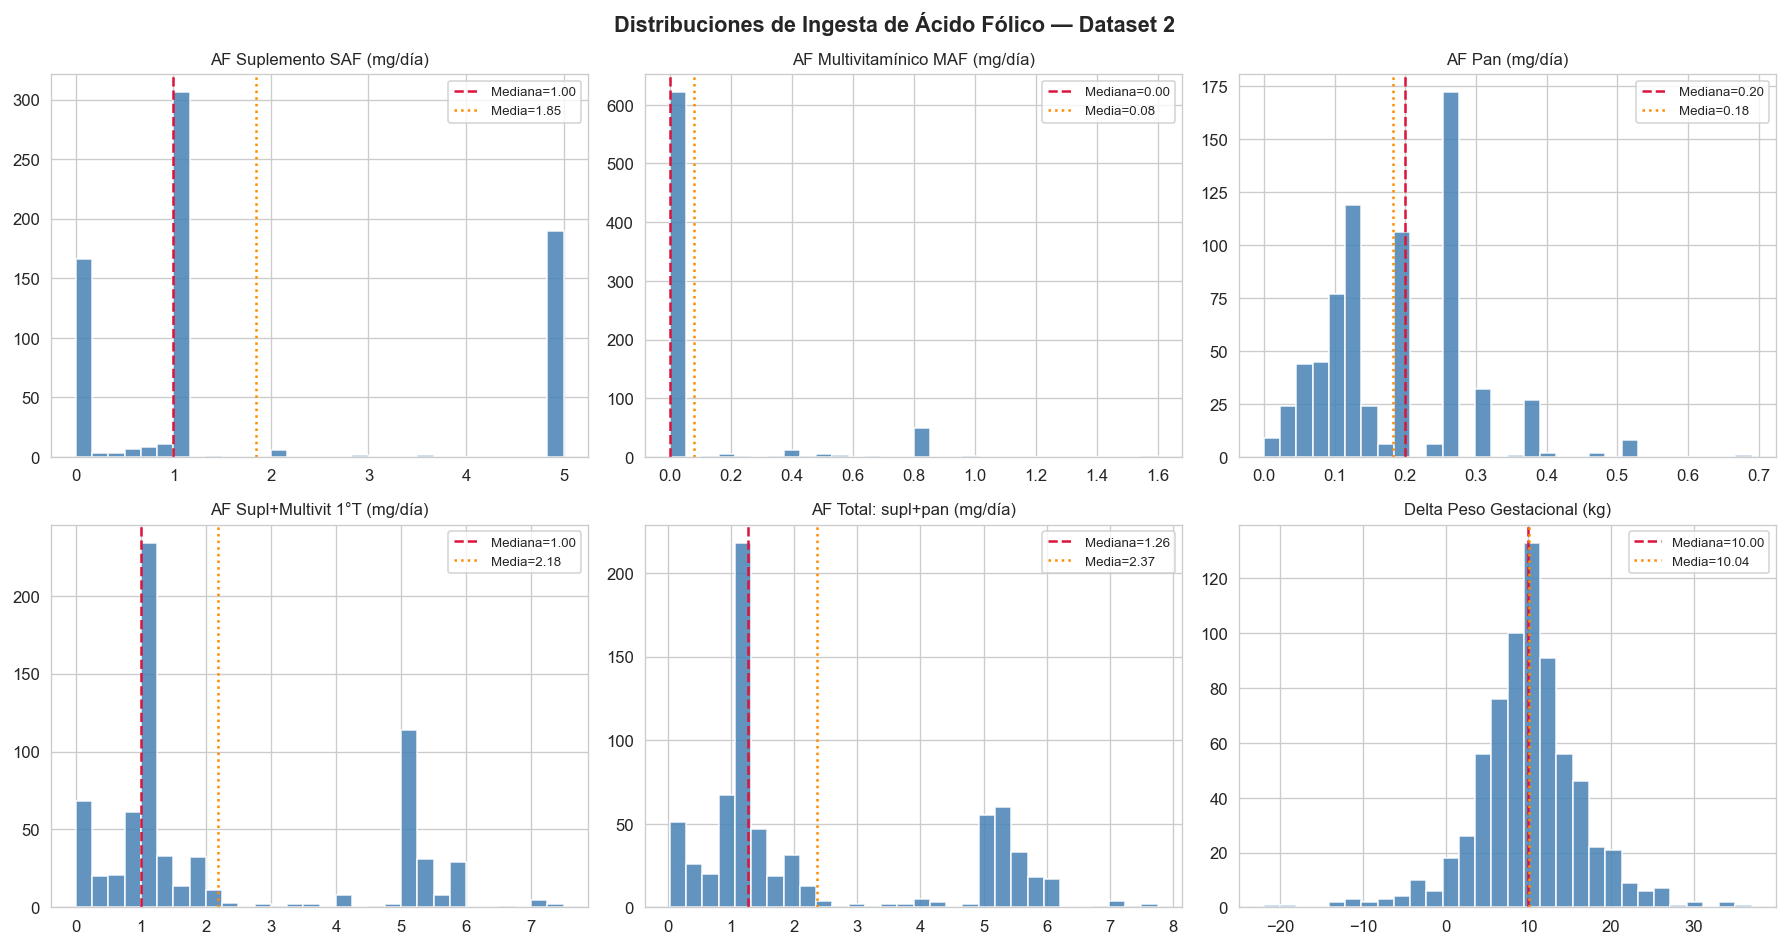

Guardado en outputs/S1_dist_af_ds2.png


In [7]:
# ── Distribuciones: variables de ingesta de AF (Dataset 2) ───────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribuciones de Ingesta de Ácido Fólico — Dataset 2', fontsize=13, fontweight='bold')

plot_vars = [
    ('mgAF/día SAF', 'AF Suplemento SAF (mg/día)'),
    ('mgAF/día MAF 1°T', 'AF Multivitamínico MAF (mg/día)'),
    ('mg/d AF total pan', 'AF Pan (mg/día)'),
    ('mgAF/día Suplementos y multivitamínico 1°T', 'AF Supl+Multivit 1°T (mg/día)'),
    ('Total mg/d AF  suple y pan', 'AF Total: supl+pan (mg/día)'),
    ('Dif peso mamá', 'Delta Peso Gestacional (kg)'),
]

for ax, (var, label) in zip(axes.flat, plot_vars):
    data = pd.to_numeric(df2[var], errors='coerce').dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='crimson', linewidth=1.5, linestyle='--', label=f'Mediana={data.median():.2f}')
    ax.axvline(data.mean(), color='darkorange', linewidth=1.5, linestyle=':', label=f'Media={data.mean():.2f}')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S1_dist_af_ds2.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado en outputs/S1_dist_af_ds2.png')


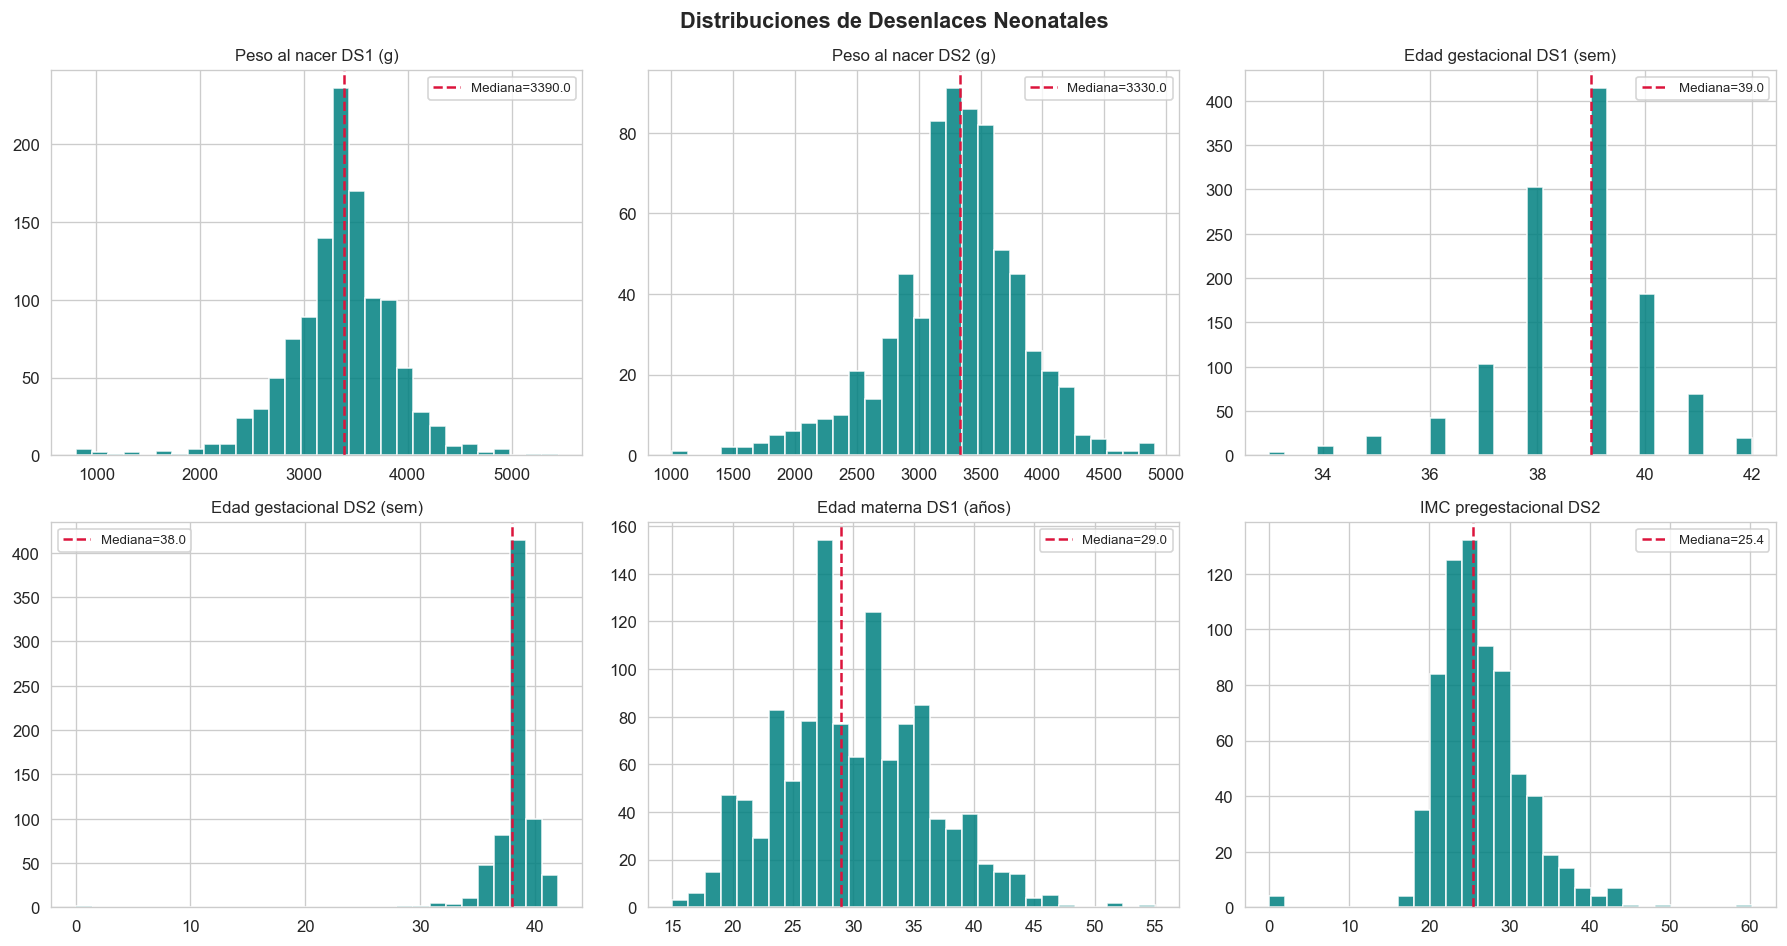

In [8]:
# ── Distribuciones: desenlaces neonatales (ambos datasets) ───────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribuciones de Desenlaces Neonatales', fontsize=13, fontweight='bold')

plot_config = [
    (df1, 'pnacer',                      'Peso al nacer DS1 (g)'),
    (df2, 'PN hijo (g)',                  'Peso al nacer DS2 (g)'),
    (df1, 'edad_gestacion_ultimo_hijo',   'Edad gestacional DS1 (sem)'),
    (df2, 'EG hijo (sem)',                'Edad gestacional DS2 (sem)'),
    (df1, 'edad',                         'Edad materna DS1 (años)'),
    (df2, 'IMC antes',                    'IMC pregestacional DS2'),
]

for ax, (df, var, label) in zip(axes.flat, plot_config):
    data = pd.to_numeric(df[var], errors='coerce').dropna()
    ax.hist(data, bins=30, color='teal', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='crimson', linewidth=1.5, linestyle='--', label=f'Mediana={data.median():.1f}')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S1_dist_desenlaces.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


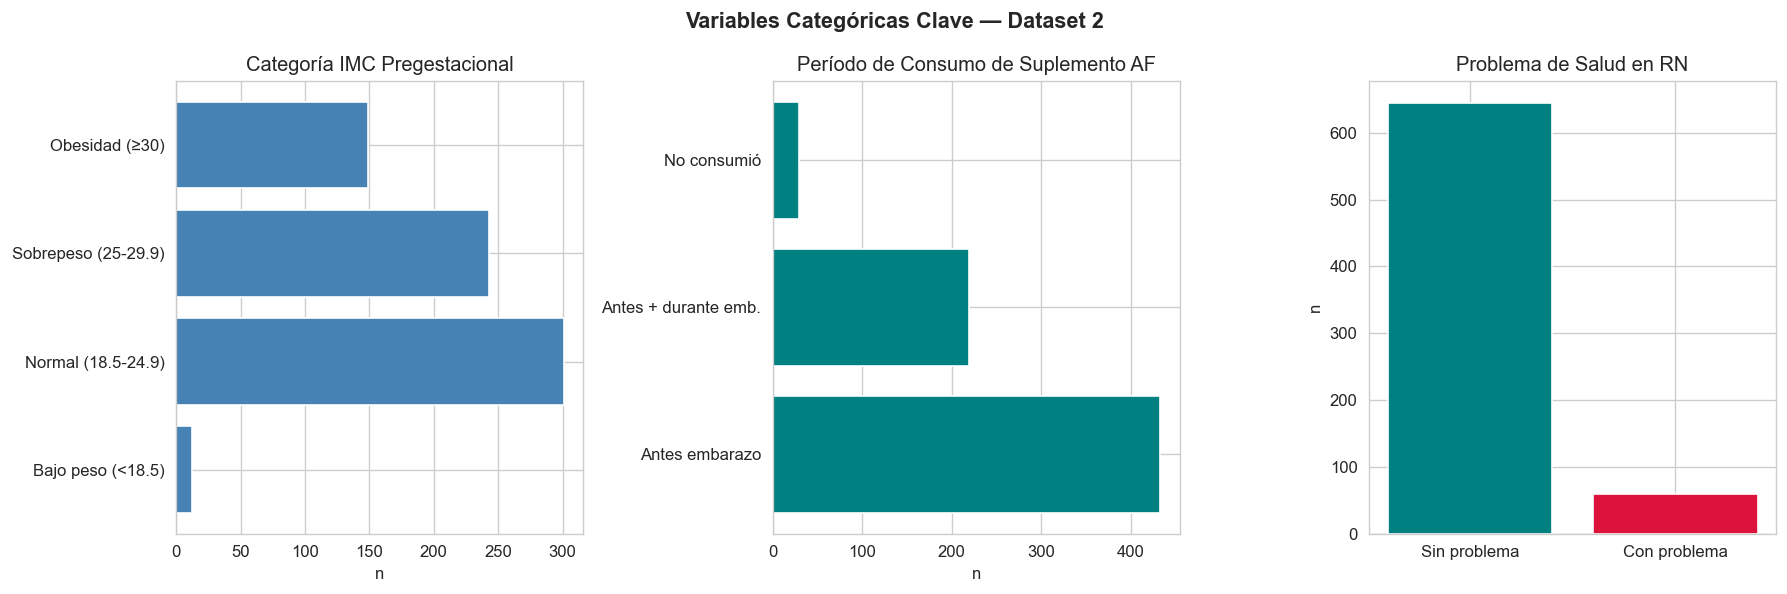

In [9]:
# ── Distribuciones categóricas clave (Dataset 2) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Variables Categóricas Clave — Dataset 2', fontsize=13, fontweight='bold')

# Categoría IMC — derived from 'IMC antes'
imc_vals = pd.to_numeric(df2['IMC antes'], errors='coerce')
bins_imc = [0, 18.5, 25, 30, 100]
labels_imc = ['Bajo peso (<18.5)', 'Normal (18.5-24.9)', 'Sobrepeso (25-29.9)', 'Obesidad (≥30)']
df2['categoria_imc_calc'] = pd.cut(imc_vals, bins=bins_imc, labels=labels_imc, right=False)
counts_imc = df2['categoria_imc_calc'].value_counts().reindex(labels_imc, fill_value=0)
axes[0].barh(counts_imc.index, counts_imc.values, color='steelblue')
axes[0].set_title('Categoría IMC Pregestacional')
axes[0].set_xlabel('n')

# Período consumo SAF
periodo_map = {
    1: 'No consumió',
    2: 'Antes embarazo',
    3: 'Antes + durante emb.',
}
periodo_vals = pd.to_numeric(df2['Período consumo SAF+OSAF'], errors='coerce')
periodo_counts = periodo_vals.map(periodo_map).value_counts()
axes[1].barh(periodo_counts.index, periodo_counts.values, color='teal')
axes[1].set_title('Período de Consumo de Suplemento AF')
axes[1].set_xlabel('n')

# Problema salud RN
salud_rn = pd.to_numeric(df2['¿Hijo nace c/problema de salud?'], errors='coerce').value_counts()
labels_rn_plot = ['Sin problema', 'Con problema']
# Assuming 0/1 or 1/2 coding; adapt based on actual values
val_sin = salud_rn.get(0, salud_rn.get(2, 0))
val_con = salud_rn.get(1, 0)
axes[2].bar(labels_rn_plot, [val_sin, val_con], color=['teal', 'crimson'])
axes[2].set_title('Problema de Salud en RN')
axes[2].set_ylabel('n')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S1_categoricas.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


### 2.3 Análisis de Valores Faltantes


In [10]:
# ── Reporte de missingness Dataset 1 ─────────────────────────────────────
miss1 = df1.isnull().sum()
miss1_pct = (miss1 / len(df1) * 100).round(2)
miss_report1 = pd.DataFrame({'n_faltantes': miss1, 'pct_faltantes': miss1_pct})
miss_report1 = miss_report1[miss_report1['n_faltantes'] > 0].sort_values('pct_faltantes', ascending=False)

print('=== Variables con valores faltantes — Dataset 1 ===')
print(miss_report1)
print()
print("NOTA: 'uf_af' y 'consumio_saf_binario' tienen 44.7% de faltantes porque corresponden")
print("a mujeres que NO consumieron suplemento — el valor faltante es informativo (MNAR).")


=== Variables con valores faltantes — Dataset 1 ===
                                               n_faltantes  pct_faltantes
uf_af                                                  523         44.700
consumio_saf_binario                                   523         44.700
fnacimiento                                            133         11.370
otro                                                     2          0.170
diabetes_gestacional                                     1          0.090
embarazo_multiple                                        1          0.090
restriccion_del_crecimiento_intrauterino_rciu            1          0.090

NOTA: 'uf_af' y 'consumio_saf_binario' tienen 44.7% de faltantes porque corresponden
a mujeres que NO consumieron suplemento — el valor faltante es informativo (MNAR).


In [11]:
# ── Visualización de missingness Dataset 2 ───────────────────────────────
miss2 = df2.isnull().sum()
miss2_pct = (miss2 / len(df2) * 100).round(2)
miss_report2 = pd.DataFrame({'n_faltantes': miss2, 'pct_faltantes': miss2_pct})
miss_report2 = miss_report2[miss_report2['n_faltantes'] > 0].sort_values('pct_faltantes', ascending=False)

print('=== Variables con valores faltantes — Dataset 2 ===')
print(miss_report2)


=== Variables con valores faltantes — Dataset 2 ===
Empty DataFrame
Columns: [n_faltantes, pct_faltantes]
Index: []


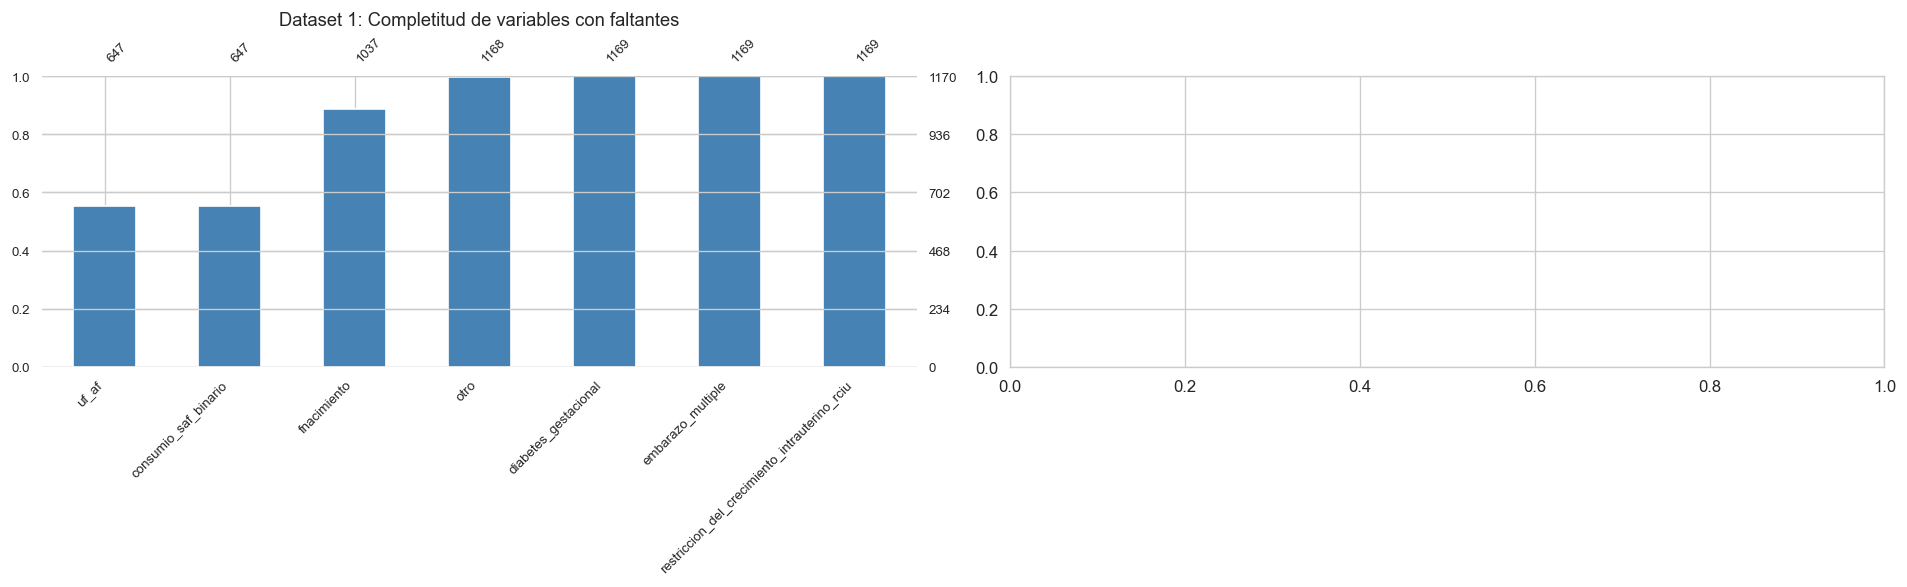

In [12]:
# ── Mapa visual de missingness ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Solo variables con algún faltante
vars_miss1 = miss_report1.index.tolist()
vars_miss2 = miss_report2[miss_report2['pct_faltantes'] > 0].index.tolist()

msno.bar(df1[vars_miss1], ax=axes[0], color='steelblue', fontsize=8)
axes[0].set_title('Dataset 1: Completitud de variables con faltantes', fontsize=11)


plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S1_missingness.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


### 2.4 Detección de Valores Atípicos


In [13]:
# ── Boxplots y detección de outliers (IQR) ───────────────────────────────
def reporte_outliers(df, var, nombre):
    data = pd.to_numeric(df[var], errors='coerce').dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    return {
        'Variable': nombre, 'N': len(data), 'Mediana': data.median(),
        'IQR': IQR, 'Límite inf': lower, 'Límite sup': upper,
        'N outliers': n_out, '% outliers': round(n_out / len(data) * 100, 2)
    }

outlier_vars = [
    (df2, 'PN hijo (g)',          'Peso RN (g)'),
    (df2, 'EG hijo (sem)',        'Edad gestacional (sem)'),
    (df2, 'IMC antes',            'IMC pregestacional'),
    (df2, 'Dif peso mamá',        'Delta peso gestacional'),
    (df2, 'mgAF/día SAF',         'AF suplementos SAF (mg/día)'),
    (df2, 'Total mg/d AF  suple y pan', 'AF total supl+pan (mg/día)'),
]

outlier_report = pd.DataFrame([reporte_outliers(df, var, nom) for df, var, nom in outlier_vars])
print('=== Reporte de Valores Atípicos (criterio IQR) ===')
outlier_report.set_index('Variable')


=== Reporte de Valores Atípicos (criterio IQR) ===


,N,Mediana,IQR,Límite inf,Límite sup,N outliers,% outliers
Variable,,,,,,,
Peso RN (g),705,3330.000,560.000,2200.000,4440.000,34,4.820
Edad gestacional (sem),705,38.000,1.000,36.500,40.500,109,15.460
IMC pregestacional,705,25.390,6.230,13.765,38.685,24,3.400
Delta peso gestacional,705,10.000,6.000,-2.000,22.000,48,6.810
AF suplementos SAF (mg/día),705,1.000,4.429,-6.073,11.643,0,0.000
AF total supl+pan (mg/día),705,1.260,4.005,-4.948,11.073,0,0.000


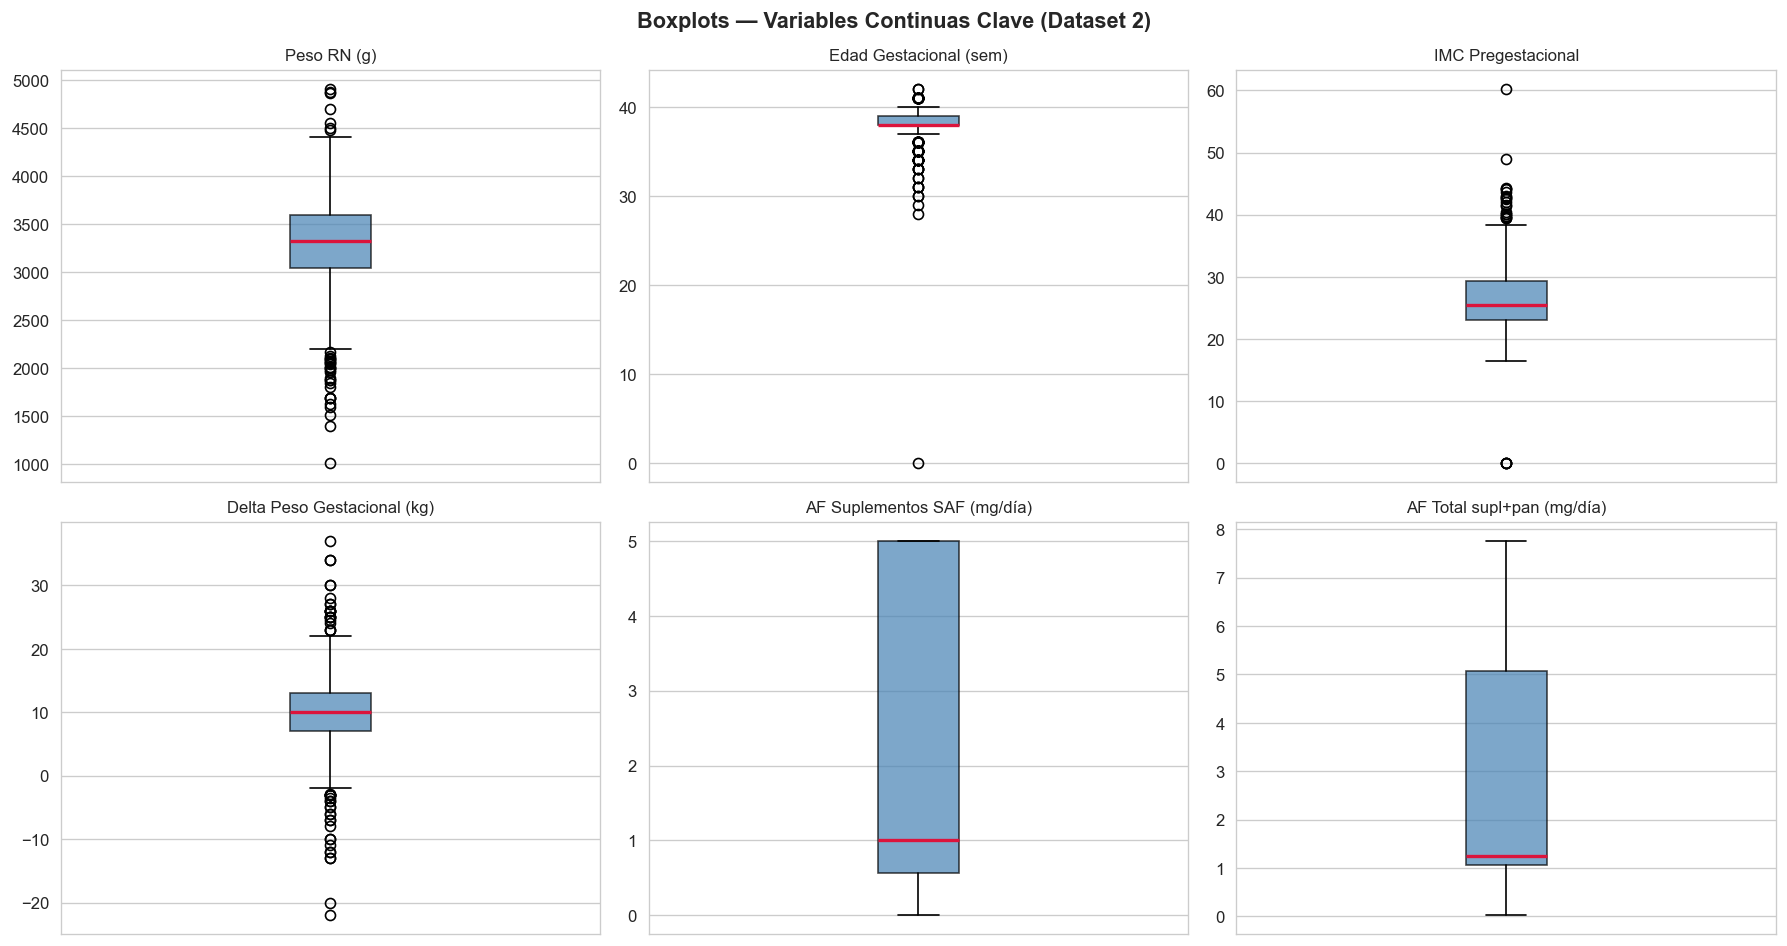

In [14]:
# ── Boxplots para variables continuas clave ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Boxplots — Variables Continuas Clave (Dataset 2)', fontsize=13, fontweight='bold')

bvars = [
    ('PN hijo (g)', 'Peso RN (g)'),
    ('EG hijo (sem)', 'Edad Gestacional (sem)'),
    ('IMC antes', 'IMC Pregestacional'),
    ('Dif peso mamá', 'Delta Peso Gestacional (kg)'),
    ('mgAF/día SAF', 'AF Suplementos SAF (mg/día)'),
    ('Total mg/d AF  suple y pan', 'AF Total supl+pan (mg/día)'),
]

for ax, (var, label) in zip(axes.flat, bvars):
    data = pd.to_numeric(df2[var], errors='coerce').dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='crimson', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_xticks([])

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S1_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


### 2.5 Matrices de Correlación


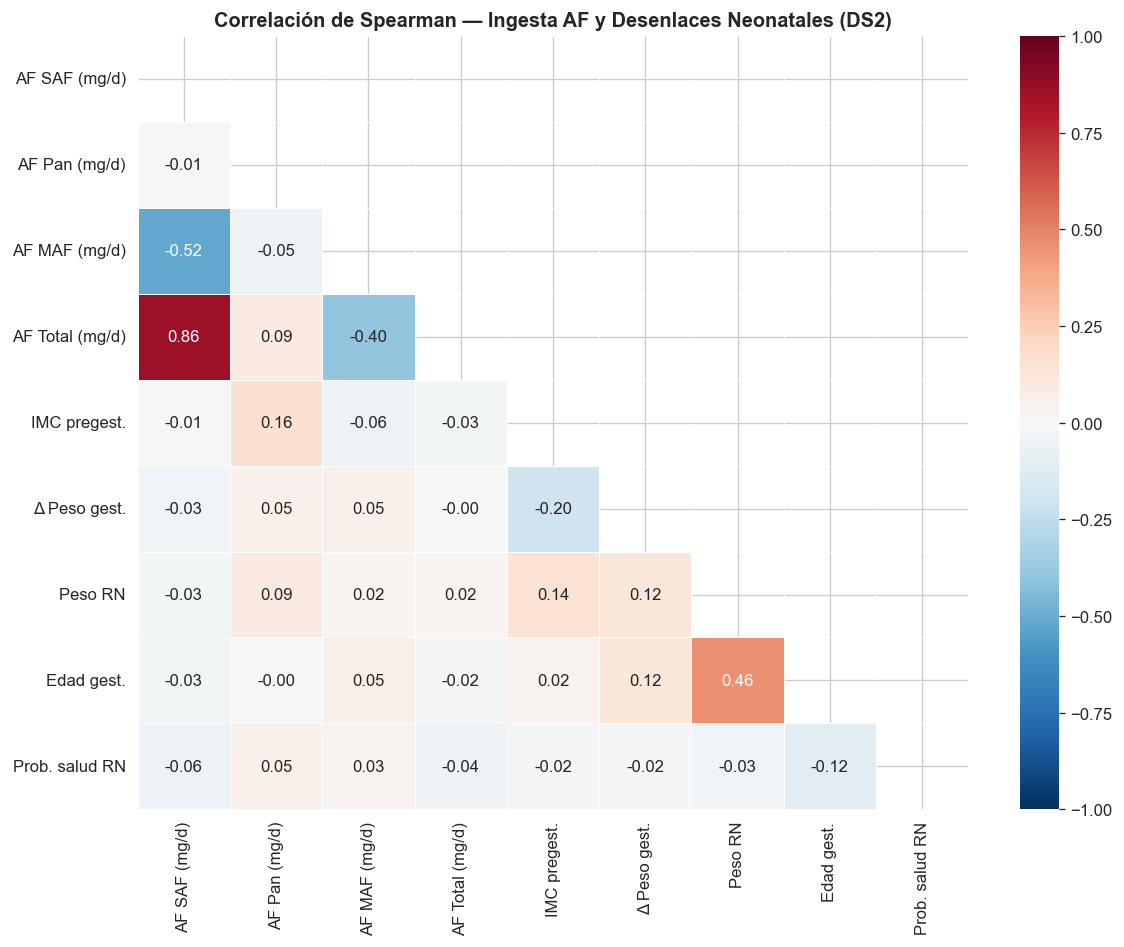

In [15]:
# ── Correlación: espacio AF + desenlaces neonatales (Dataset 2) ──────────
corr_vars = [
    'mgAF/día SAF', 'mg/d AF total pan', 'mgAF/día MAF 1°T',
    'Total mg/d AF  suple y pan',
    'IMC antes', 'Dif peso mamá',
    'PN hijo (g)', 'EG hijo (sem)', '¿Hijo nace c/problema de salud?'
]
labels_corr = [
    'AF SAF (mg/d)', 'AF Pan (mg/d)', 'AF MAF (mg/d)',
    'AF Total (mg/d)',
    'IMC pregest.', 'Δ Peso gest.',
    'Peso RN', 'Edad gest.', 'Prob. salud RN'
]

corr_df = df2[corr_vars].apply(pd.to_numeric, errors='coerce').copy()
corr_df.columns = labels_corr
corr_matrix = corr_df.corr(method='spearman')  # Spearman por distribuciones no normales

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title('Correlación de Spearman — Ingesta AF y Desenlaces Neonatales (DS2)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S1_correlacion.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


### 2.6 Análisis Bivariado: Ingesta de AF vs. Desenlaces Neonatales


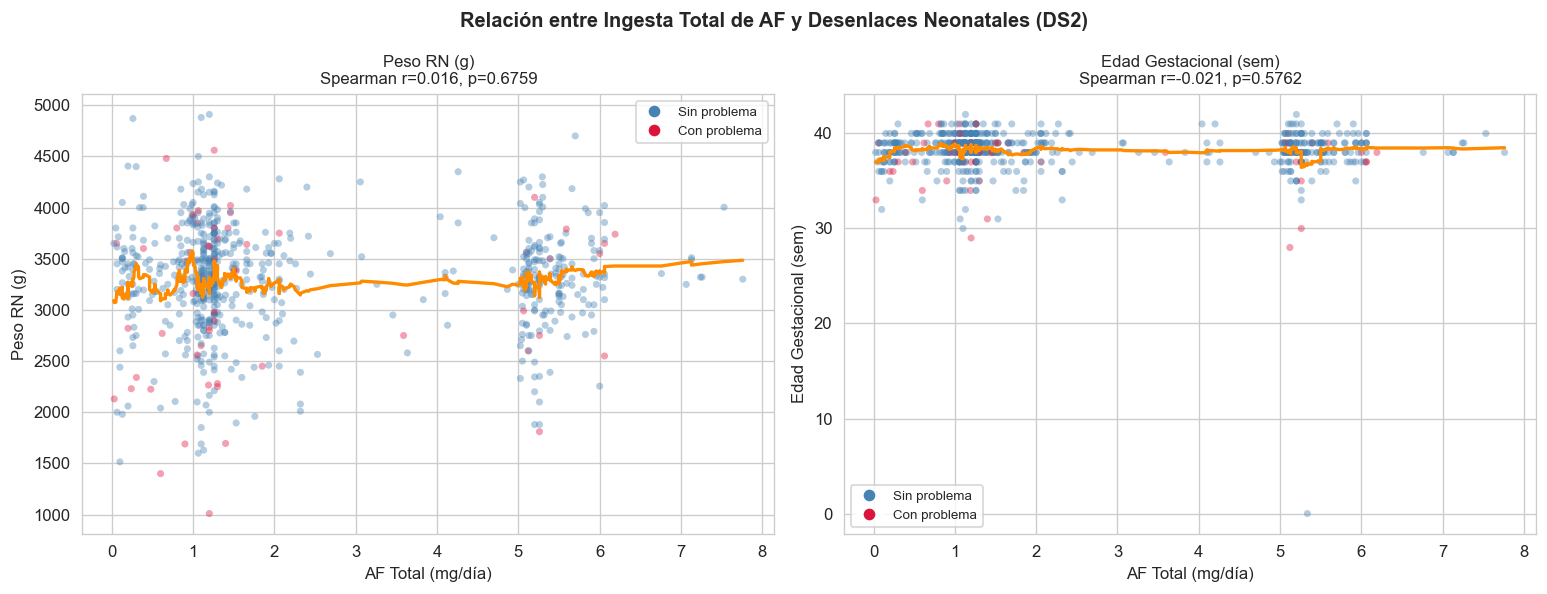

In [16]:
# ── Scatterplots: AF total vs. peso RN y edad gestacional ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Relación entre Ingesta Total de AF y Desenlaces Neonatales (DS2)', fontsize=12, fontweight='bold')

for ax, (yvar, ylabel) in zip(axes, [('PN hijo (g)', 'Peso RN (g)'), ('EG hijo (sem)', 'Edad Gestacional (sem)')]):
    sub = df2[['Total mg/d AF  suple y pan', yvar, '¿Hijo nace c/problema de salud?']].copy()
    sub = sub.apply(pd.to_numeric, errors='coerce').dropna()
    colors = sub['¿Hijo nace c/problema de salud?'].map({0: 'steelblue', 1: 'crimson', 2: 'steelblue'})
    ax.scatter(sub['Total mg/d AF  suple y pan'], sub[yvar],
               c=colors, alpha=0.4, s=18, edgecolors='none')
    # Tendencia suavizada
    from scipy.stats import pearsonr
    x_s = sub['Total mg/d AF  suple y pan'].values
    y_s = sub[yvar].values
    idx = np.argsort(x_s)
    from scipy.ndimage import uniform_filter1d
    y_smooth = uniform_filter1d(y_s[idx], size=30)
    ax.plot(x_s[idx], y_smooth, color='darkorange', linewidth=2, label='Tendencia suavizada')
    r, p = stats.spearmanr(x_s, y_s)
    ax.set_xlabel('AF Total (mg/día)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{ylabel}\nSpearman r={r:.3f}, p={p:.4f}', fontsize=10)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', label='Sin problema', markersize=8),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', label='Con problema', markersize=8),
    ]
    ax.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S1_bivariado_af_desenlaces.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


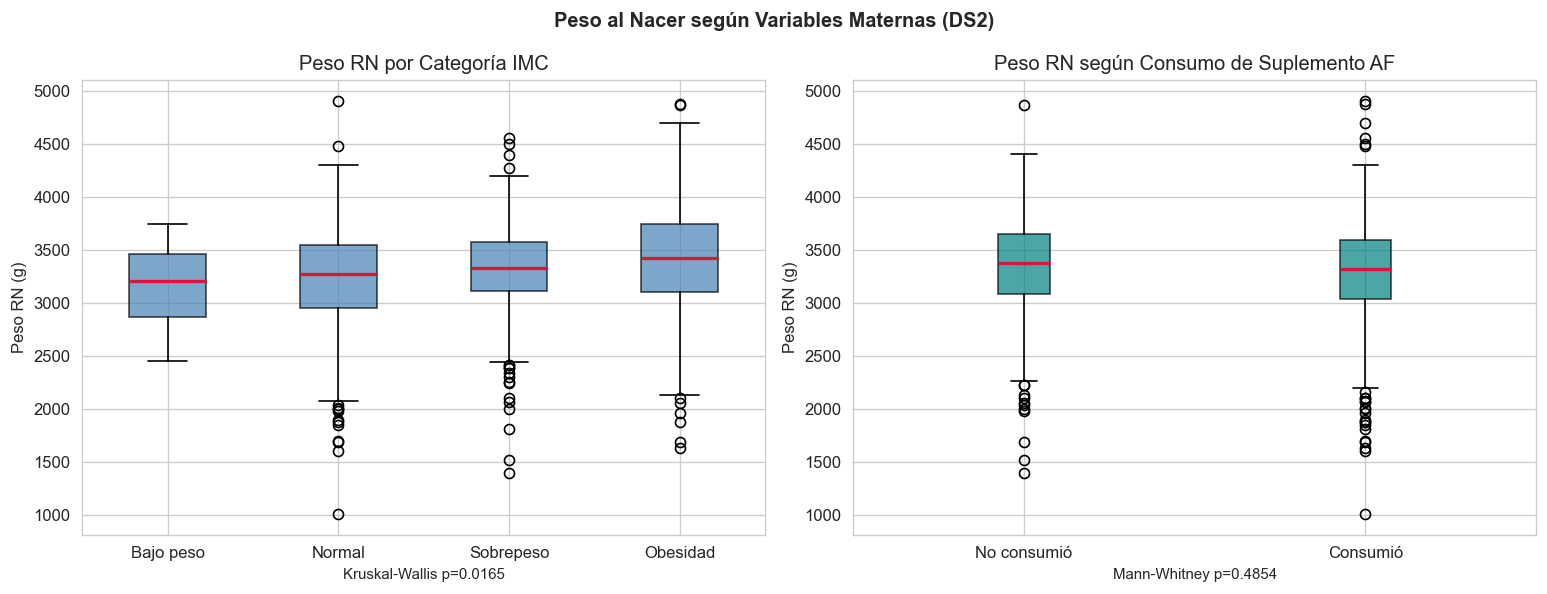

In [17]:
# ── Peso RN por categoría IMC y consumo de suplemento AF ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Peso al Nacer según Variables Maternas (DS2)', fontsize=12, fontweight='bold')

# Create derived columns for analysis
imc_vals = pd.to_numeric(df2['IMC antes'], errors='coerce')
bins_imc = [0, 18.5, 25, 30, 100]
cat_order_imc = ['Bajo peso (<18.5)', 'Normal (18.5-24.9)', 'Sobrepeso (25-29.9)', 'Obesidad (≥30)']
df2['_cat_imc'] = pd.cut(imc_vals, bins=bins_imc, labels=cat_order_imc, right=False)
df2['_peso_rn'] = pd.to_numeric(df2['PN hijo (g)'], errors='coerce')

# Por categoría IMC
sub_imc = df2[df2['_cat_imc'].isin(cat_order_imc)].copy()
groups_imc = [sub_imc.loc[sub_imc['_cat_imc'] == c, '_peso_rn'].dropna().values for c in cat_order_imc]
# Filter out empty groups
non_empty_imc = [(c, g) for c, g in zip(cat_order_imc, groups_imc) if len(g) > 0]
axes[0].boxplot([g for _, g in non_empty_imc],
                labels=[c.split('(')[0].strip() for c, _ in non_empty_imc],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='crimson', linewidth=2))
axes[0].set_title('Peso RN por Categoría IMC')
axes[0].set_ylabel('Peso RN (g)')
if len(non_empty_imc) >= 2:
    stat, p = stats.kruskal(*[g for _, g in non_empty_imc])
    axes[0].set_xlabel(f'Kruskal-Wallis p={p:.4f}', fontsize=9)

# Por consumo SAF
consumo_saf = pd.to_numeric(df2['¿Consume SAF?'], errors='coerce')
peso_rn_num = pd.to_numeric(df2['PN hijo (g)'], errors='coerce')
# Detect coding: could be 0/1 or 1/2
saf_values = consumo_saf.dropna().unique()
if set(saf_values).issubset({0, 1}):
    no_val, si_val = 0, 1
else:
    no_val, si_val = sorted(saf_values)[:2]  # assume first = no, second = si

groups_saf = [
    peso_rn_num[consumo_saf == no_val].dropna().values,
    peso_rn_num[consumo_saf == si_val].dropna().values
]
axes[1].boxplot(groups_saf, labels=['No consumió', 'Consumió'],
                patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.7),
                medianprops=dict(color='crimson', linewidth=2))
axes[1].set_title('Peso RN según Consumo de Suplemento AF')
axes[1].set_ylabel('Peso RN (g)')
if len(groups_saf[0]) > 0 and len(groups_saf[1]) > 0:
    stat_s, p_s = stats.mannwhitneyu(*groups_saf, alternative='two-sided')
    axes[1].set_xlabel(f'Mann-Whitney p={p_s:.4f}', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S1_peso_rn_grupos.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


---
## 3. Estrategia de Aislamiento de Covariables `[T1.3]`

Para estudiar el efecto **neto** de la ingesta de AF sobre los desenlaces neonatales, es necesario
neutralizar el efecto de variables confusoras: **edad materna**, **nivel educativo**, **IMC pregestacional**
y **número de embarazos**.

**Estrategia seleccionada:** Regresión lineal múltiple para generar **residuales ajustados** de cada
desenlace. Los residuales representan la variación en el desenlace que no es explicada por las
covariables socioeconómicas/de salud, capturando así el efecto potencial del AF y otros factores.

Esta estrategia se aplica sobre el **Dataset 2**, que cuenta con las variables de AF cuantificadas en mg/día.


In [18]:
# ── Aislamiento de covariables: construcción de residuales ───────────────

COVARIABLES = ['Edad madre', 'Educación', 'IMC antes',
               'N° embarazo', 'Período']
OUTCOMES    = ['PN hijo (g)', 'EG hijo (sem)', 'Dif peso mamá']

# Subset con covariables y desenlaces completos
df2_adj = df2[COVARIABLES + OUTCOMES + ['Total mg/d AF  suple y pan',
               'mgAF/día SAF', '¿Hijo nace c/problema de salud?']].copy()

# Convert all to numeric
for col in df2_adj.columns:
    df2_adj[col] = pd.to_numeric(df2_adj[col], errors='coerce')

# Imputar faltantes en covariables con mediana (conservador)
for col in COVARIABLES:
    df2_adj[col].fillna(df2_adj[col].median(), inplace=True)

df2_adj.dropna(subset=OUTCOMES, inplace=True)

residuales = {}
for outcome in OUTCOMES:
    sub = df2_adj[COVARIABLES + [outcome]].dropna()
    X = sub[COVARIABLES].values
    y = sub[outcome].values
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    reg = LinearRegression().fit(X_scaled, y)
    y_pred = reg.predict(X_scaled)
    res = y - y_pred
    residuales[outcome + '_residual'] = pd.Series(res, index=sub.index)
    r2 = reg.score(X_scaled, y)
    print(f'{outcome}: R² covariables = {r2:.4f}  → {r2*100:.1f}% de varianza explicada por confusores')

# Agregar residuales al DataFrame principal
for col, series in residuales.items():
    df2_adj[col] = series

print(f'\nDataset ajustado: {df2_adj.shape[0]} registros')
print('Variables de residuales generadas:', list(residuales.keys()))


PN hijo (g): R² covariables = 0.0283  → 2.8% de varianza explicada por confusores
EG hijo (sem): R² covariables = 0.0144  → 1.4% de varianza explicada por confusores
Dif peso mamá: R² covariables = 0.0886  → 8.9% de varianza explicada por confusores

Dataset ajustado: 705 registros
Variables de residuales generadas: ['PN hijo (g)_residual', 'EG hijo (sem)_residual', 'Dif peso mamá_residual']


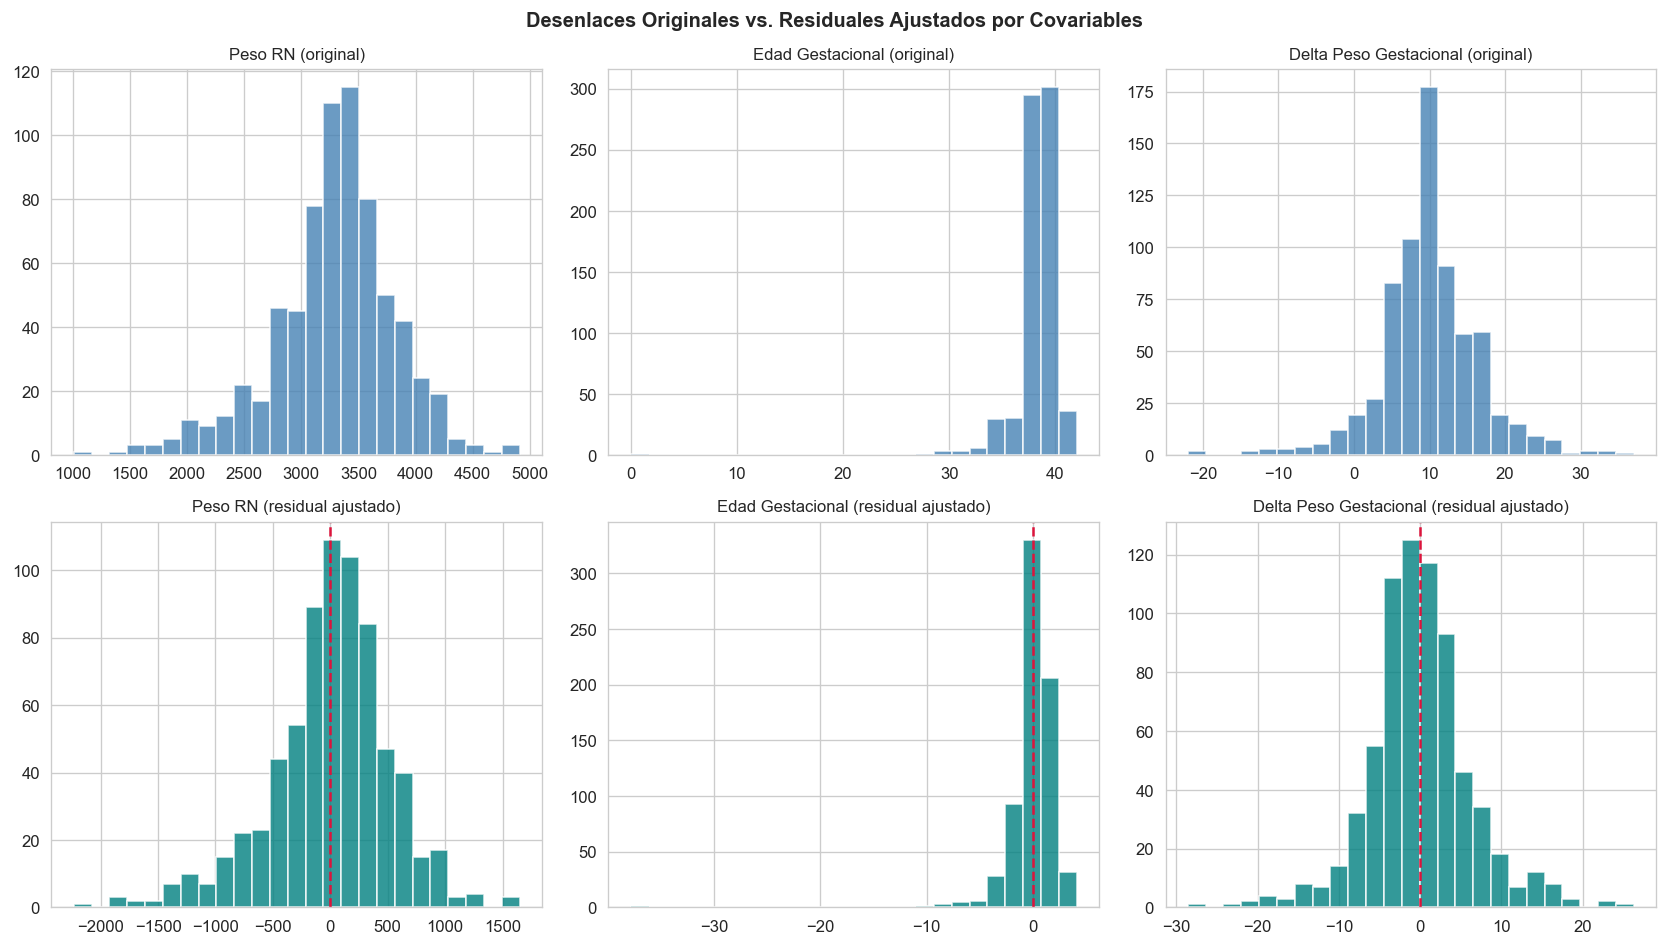

In [19]:
# ── Visualización: desenlaces originales vs. residuales ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Desenlaces Originales vs. Residuales Ajustados por Covariables', fontsize=12, fontweight='bold')

pairs = [
    ('PN hijo (g)',       'PN hijo (g)_residual',       'Peso RN'),
    ('EG hijo (sem)',     'EG hijo (sem)_residual',     'Edad Gestacional'),
    ('Dif peso mamá',    'Dif peso mamá_residual',    'Delta Peso Gestacional'),
]

for i, (orig, resid, name) in enumerate(pairs):
    # Original
    axes[0, i].hist(df2_adj[orig].dropna(), bins=25, color='steelblue', alpha=0.8)
    axes[0, i].set_title(f'{name} (original)', fontsize=10)

    # Residual
    if resid in df2_adj.columns:
        axes[1, i].hist(df2_adj[resid].dropna(), bins=25, color='teal', alpha=0.8)
        axes[1, i].axvline(0, color='crimson', linewidth=1.5, linestyle='--')
        axes[1, i].set_title(f'{name} (residual ajustado)', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S1_residuales.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


---
## 4. Diseño del Pipeline TDA `[T1.4]`

El pipeline sigue la arquitectura definida en la Sección 2 del plan de trabajo. El diagrama a continuación
esquematiza el flujo completo, que se ejecuta en la Semana 2:

```
Dataset 2 (850 × 91)
        │
        ▼
[T2.1] Preprocesamiento
       • Imputación de faltantes
       • Normalización (StandardScaler)
       • Codificación de categóricas
       • Construcción de espacio AF y espacio neonatal
        │
        ├──────────────────────────────────┐
        ▼                                  ▼
[T2.2] Clustering Clásico          [T2.3+T2.4] Mapper TDA
       • K-Means                   • Lente 1: UMAP sobre espacio AF
       • Jerárquico (Ward)         • Lente 2: UMAP sobre desenlaces neonatales
       • Validación:               • Cover: resolución=15, ganancia=0.4
         Silhouette, CH, DB        • Clustering interno: DBSCAN
        │                                  │
        └────────────┬─────────────────────┘
                     ▼
              [T2.5] Comparación e Interpretación
              • Solapamiento de nodos
              • Caracterización de subpoblaciones
                     │
                     ▼
              [T2.6] Homología Persistente
              • Diagramas de persistencia (β0, β1)
              • Barcode plots
                     │
                     ▼
              [Semana 3] Análisis ML
              • Random Forest sobre nodos Mapper
              • SHAP para interpretabilidad
```


In [20]:
# ── Resumen del espacio de características para cada etapa ───────────────
pipeline_summary = pd.DataFrame({
    'Etapa': ['Clustering clásico', 'Mapper lente AF', 'Mapper lente neonatal', 'Homología persistente'],
    'Dataset': ['DS2', 'DS2', 'DS2', 'DS2'],
    'Variables de entrada': [
        'Total AF suple+pan + SAF mg/d + Pan mg/d + IMC + Dif peso + Período consumo',
        'SAF mg/d + MAF mg/d + Pan mg/d + Período consumo (UMAP 2D)',
        'Peso RN + EG + Dif peso gest + IMC pregest + Problema RN (UMAP 2D)',
        'Espacio AF completo (Rips complex)'
    ],
    'Método de proyección': ['—', 'UMAP', 'UMAP', 'Ripser (distancia Euclidea/coseno)'],
    'Salida': [
        'Etiqueta de cluster (k óptimo)',
        'Grafo Mapper + nodos',
        'Grafo Mapper + nodos',
        'Diagramas de persistencia'
    ]
})
print('=== Pipeline TDA — Resumen de etapas ===')
pipeline_summary


=== Pipeline TDA — Resumen de etapas ===


,Etapa,Dataset,Variables de entrada,Método de proyección,Salida
0,Clustering clásico,DS2,Total AF suple+pan + SAF mg/d + Pan mg/d + IMC...,—,Etiqueta de cluster (k óptimo)
1,Mapper lente AF,DS2,SAF mg/d + MAF mg/d + Pan mg/d + Período consu...,UMAP,Grafo Mapper + nodos
2,Mapper lente neonatal,DS2,Peso RN + EG + Dif peso gest + IMC pregest + P...,UMAP,Grafo Mapper + nodos
3,Homología persistente,DS2,Espacio AF completo (Rips complex),Ripser (distancia Euclidea/coseno),Diagramas de persistencia


---
# SEMANA 2: Clustering Clásico y Construcción del Mapper
> **Objetivo:** Ejecutar el clustering clásico como línea base y construir los grafos Mapper con distintas
> lentes para obtener una primera versión interpretable de las subpoblaciones.

Cubre las tareas T2.1 – T2.6 del plan de trabajo.


---
## 5. Preprocesamiento Final para TDA `[T2.1]`

Se construyen dos espacios de características a partir del Dataset 2:

- **Espacio AF:** variables de ingesta cuantitativa de ácido fólico.
- **Espacio Neonatal:** variables de desenlaces materno-infantiles.

Ambos espacios se normalizan con `StandardScaler` para garantizar que todas las variables
tengan igual contribución en las métricas de distancia y en la proyección UMAP.


In [21]:
# ── Construcción del espacio AF (Dataset 2) ──────────────────────────────
AF_FEATURES = [
    'mgAF/día SAF',                  # AF de suplementos SAF (mg/día)
    'mgAF/día MAF 1°T',              # AF de multivitamínico MAF (mg/día)
    'mg/d AF total pan',              # AF de pan (mg/día)
    'Total mg/d AF  suple y pan',     # AF total (supl + pan)
    'Período consumo SAF+OSAF',       # Período de consumo (codificado)
    '¿Consume SAF?',                  # Consumió suplemento AF (binario)
    'Consumo OSAF completo',          # Consumió otro suplemento AF
    '¿Consumió MAF?',                 # Consumió multivitamínico con AF
]

NEONATAL_FEATURES = [
    'PN hijo (g)',                     # Peso al nacer (g)
    'EG hijo (sem)',                   # Edad gestacional (semanas)
    'Dif peso mamá',                   # Delta peso gestacional (kg)
    'IMC antes',                       # IMC pregestacional
    '¿Hijo nace c/problema de salud?', # Problema de salud en RN (binario)
]

ALL_FEATURES = list(set(AF_FEATURES + NEONATAL_FEATURES))

# Dataset de trabajo: eliminar filas con faltantes en las features seleccionadas
df_tda = df2[ALL_FEATURES].copy()

# Convert all to numeric
for col in df_tda.columns:
    df_tda[col] = pd.to_numeric(df_tda[col], errors='coerce')

# Imputar faltantes numéricos con mediana
for col in df_tda.columns:
    if df_tda[col].dtype in ['float64', 'int64']:
        df_tda[col].fillna(df_tda[col].median(), inplace=True)

df_tda.dropna(inplace=True)
print(f'Dataset TDA: {df_tda.shape[0]} registros × {df_tda.shape[1]} variables')
print(f'Variables AF: {AF_FEATURES}')
print(f'Variables neonatales: {NEONATAL_FEATURES}')


Dataset TDA: 705 registros × 13 variables
Variables AF: ['mgAF/día SAF', 'mgAF/día MAF 1°T', 'mg/d AF total pan', 'Total mg/d AF  suple y pan', 'Período consumo SAF+OSAF', '¿Consume SAF?', 'Consumo OSAF completo', '¿Consumió MAF?']
Variables neonatales: ['PN hijo (g)', 'EG hijo (sem)', 'Dif peso mamá', 'IMC antes', '¿Hijo nace c/problema de salud?']


In [22]:
# ── Normalización y construcción de espacios ──────────────────────────────
scaler = StandardScaler()

# Forzar tipos numéricos
df_tda[AF_FEATURES] = df_tda[AF_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0)
df_tda[NEONATAL_FEATURES] = df_tda[NEONATAL_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(df_tda[NEONATAL_FEATURES].median())

# Espacio AF
X_af_raw = df_tda[AF_FEATURES].values
X_af     = scaler.fit_transform(X_af_raw)

# Espacio neonatal
X_neo_raw = df_tda[NEONATAL_FEATURES].values
X_neo     = scaler.fit_transform(X_neo_raw)

# Espacio combinado (para clustering clásico)
X_all_raw = df_tda[ALL_FEATURES].values
X_all     = StandardScaler().fit_transform(X_all_raw)

print(f'X_af (espacio AF):       {X_af.shape}')
print(f'X_neo (espacio neonatal): {X_neo.shape}')
print(f'X_all (combinado):       {X_all.shape}')
print('\nEstadísticas post-normalización (medias deben ser ~0):')
print(f'  X_af  media={X_af.mean():.4f}, std={X_af.std():.4f}')
print(f'  X_neo media={X_neo.mean():.4f}, std={X_neo.std():.4f}')


X_af (espacio AF):       (705, 8)
X_neo (espacio neonatal): (705, 5)
X_all (combinado):       (705, 13)

Estadísticas post-normalización (medias deben ser ~0):
  X_af  media=-0.0000, std=1.0000
  X_neo media=0.0000, std=1.0000


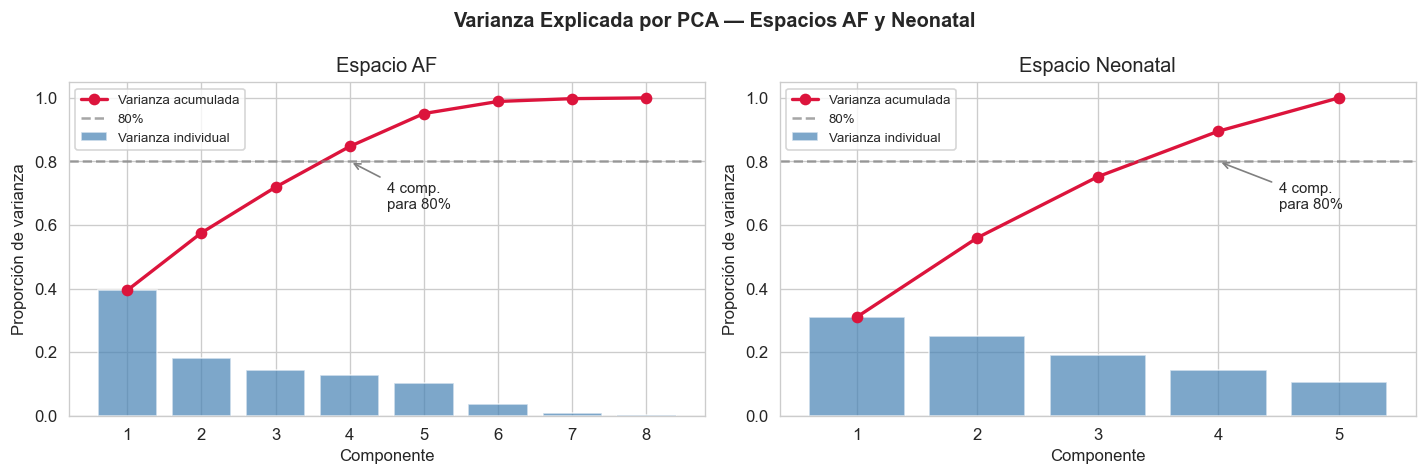

In [23]:
# ── PCA exploratoria: ¿cuánta varianza capturan las primeras componentes? ─
pca_af  = PCA().fit(X_af)
pca_neo = PCA().fit(X_neo)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Varianza Explicada por PCA — Espacios AF y Neonatal', fontsize=12, fontweight='bold')

for ax, pca, title in zip(axes, [pca_af, pca_neo], ['Espacio AF', 'Espacio Neonatal']):
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    ax.bar(range(1, len(cum_var)+1), pca.explained_variance_ratio_,
           alpha=0.7, color='steelblue', label='Varianza individual')
    ax.plot(range(1, len(cum_var)+1), cum_var, 'o-', color='crimson',
            linewidth=2, label='Varianza acumulada')
    ax.axhline(0.8, color='gray', linestyle='--', alpha=0.7, label='80%')
    ax.set_xlabel('Componente')
    ax.set_ylabel('Proporción de varianza')
    ax.set_title(title)
    ax.legend(fontsize=8)
    n80 = np.searchsorted(cum_var, 0.8) + 1
    ax.annotate(f'{n80} comp.\npara 80%', xy=(n80, 0.8), xytext=(n80+0.5, 0.65),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_pca_varianza.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


---
## 6. Clustering Clásico `[T2.2]`

Se aplican dos algoritmos de clustering sobre el espacio AF completo:

1. **K-Means:** método particional iterativo. Se determina el número óptimo de clusters
   mediante la curva del codo (inercia), el coeficiente de Silhouette y el índice de Calinski-Harabasz.
2. **Clustering jerárquico aglomerativo (Ward):** construye una jerarquía de agrupaciones
   minimizando la varianza intra-cluster. Se visualiza mediante dendrograma.

Estos clusters servirán como **línea base** para comparar con los grupos topológicos del Mapper.


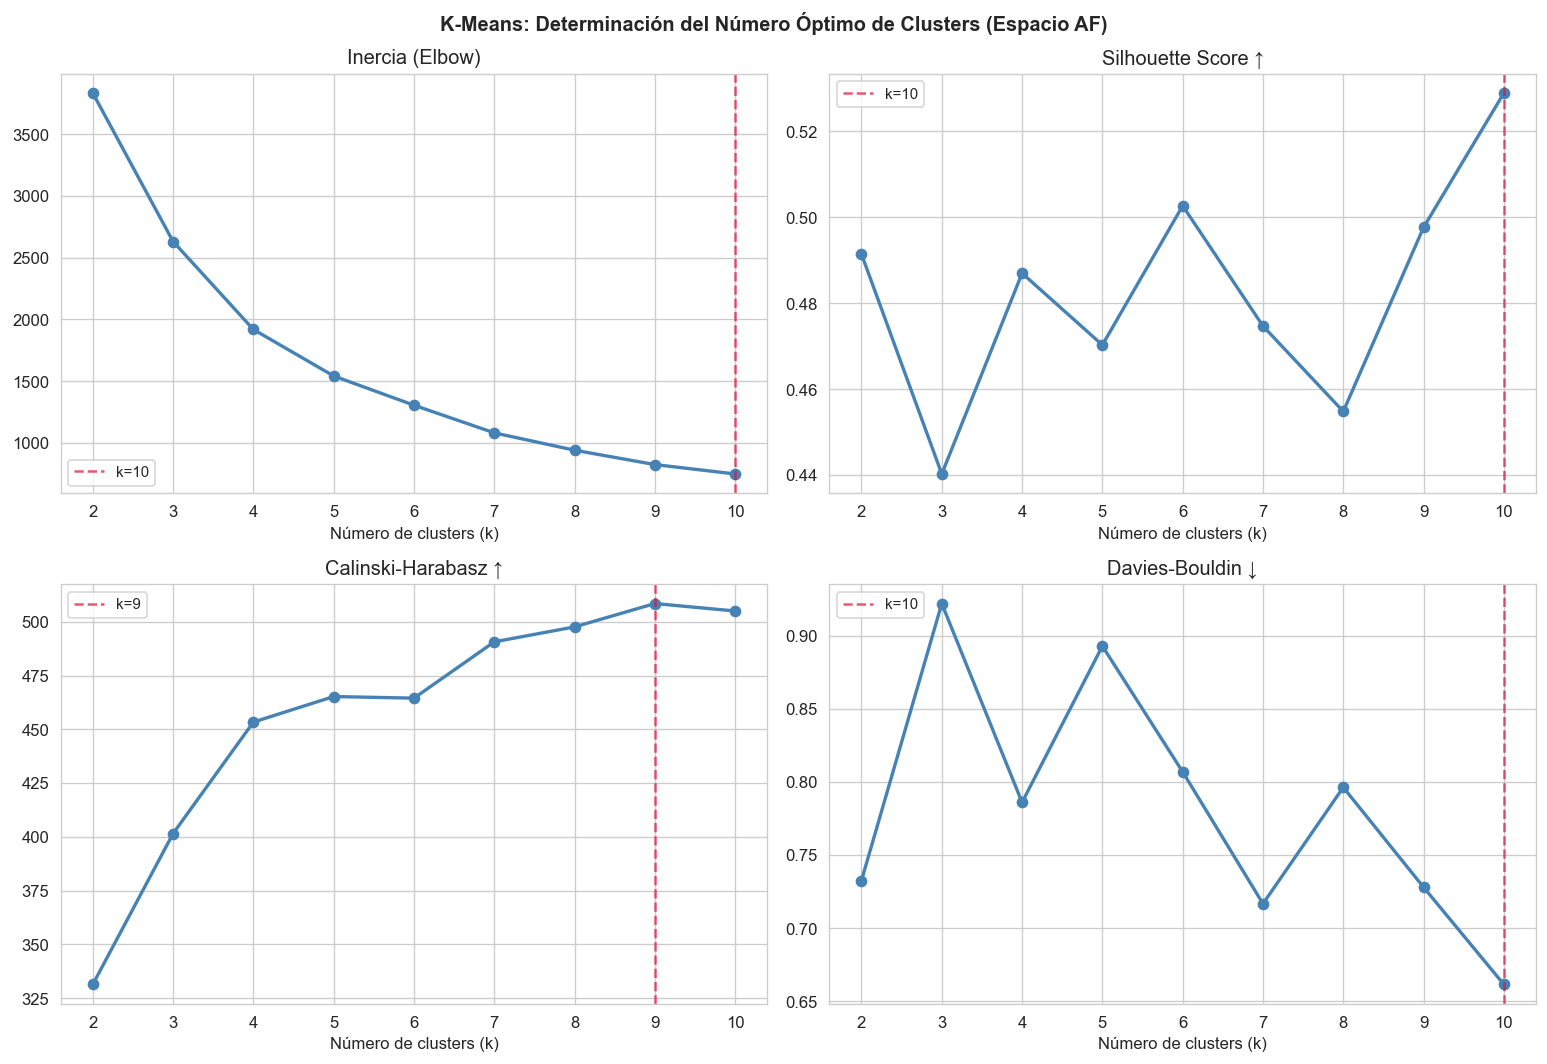

 k  Inercia  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2 3833.122       0.491            331.384           0.733
 3 2630.550       0.440            401.557           0.922
 4 1918.228       0.487            453.363           0.786
 5 1541.604       0.470            465.242           0.893
 6 1304.782       0.503            464.494           0.807
 7 1080.907       0.475            490.675           0.717
 8  940.379       0.455            497.616           0.796
 9  824.014       0.498            508.475           0.728
10  748.042       0.529            505.009           0.661


In [24]:
# ── K-Means: curva del codo y métricas de validación ─────────────────────
k_range = range(2, 11)
inertias, silhouettes, ch_scores, db_scores = [], [], [], []

for k in k_range:
    km_model = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km_model.fit_predict(X_af)
    inertias.append(km_model.inertia_)
    silhouettes.append(silhouette_score(X_af, labels))
    ch_scores.append(calinski_harabasz_score(X_af, labels))
    db_scores.append(davies_bouldin_score(X_af, labels))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('K-Means: Determinación del Número Óptimo de Clusters (Espacio AF)', fontsize=12, fontweight='bold')

for ax, vals, title, better in zip(
    axes.flat,
    [inertias, silhouettes, ch_scores, db_scores],
    ['Inercia (Elbow)', 'Silhouette Score ↑', 'Calinski-Harabasz ↑', 'Davies-Bouldin ↓'],
    [False, True, True, False]
):
    ax.plot(list(k_range), vals, 'o-', color='steelblue', linewidth=2)
    best_k = list(k_range)[np.argmax(vals) if better else np.argmin(vals)]
    ax.axvline(best_k, color='crimson', linestyle='--', alpha=0.7, label=f'k={best_k}')
    ax.set_xlabel('Número de clusters (k)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xticks(list(k_range))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_kmeans_validacion.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Resumen
val_df = pd.DataFrame({
    'k': list(k_range),
    'Inercia': inertias,
    'Silhouette': silhouettes,
    'Calinski-Harabasz': ch_scores,
    'Davies-Bouldin': db_scores
})
print(val_df.to_string(index=False))


In [25]:
# ── K-Means: ajuste con k óptimo y caracterización de clusters ────────────
# El k óptimo se selecciona maximizando el índice Silhouette
k_opt = list(k_range)[np.argmax(silhouettes)]
print(f'K óptimo seleccionado (max Silhouette): k = {k_opt}')

km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=15)
df_tda['cluster_kmeans'] = km_final.fit_predict(X_af)

# Caracterización estadística por cluster
char_vars = ['Total mg/d AF  suple y pan', 'mgAF/día SAF',
             'mg/d AF total pan', 'PN hijo (g)', 'EG hijo (sem)', 'IMC antes', 'Dif peso mamá']
char_labels = ['AF Total (mg/d)', 'AF SAF (mg/d)', 'AF Pan (mg/d)',
                'Peso RN (g)', 'Edad gest (sem)', 'IMC pregest', 'Δ Peso gest (kg)']

char_df = df_tda.copy()
for col in char_vars:
    if col not in char_df.columns:
        char_df[col] = pd.to_numeric(df2.loc[df_tda.index, col], errors='coerce')

print(f'\nTamaño de clusters:')
print(df_tda['cluster_kmeans'].value_counts().sort_index())

print('\nMedianas por cluster:')
resumen = df_tda.groupby('cluster_kmeans')[char_vars].median()
resumen.index.name = 'Cluster'
resumen.columns = char_labels
resumen


K óptimo seleccionado (max Silhouette): k = 10

Tamaño de clusters:
cluster_kmeans
0     37
1    166
2     83
3     79
4     56
5     72
6     29
7    103
8     25
9     55
Name: count, dtype: int64

Medianas por cluster:


,AF Total (mg/d),AF SAF (mg/d),AF Pan (mg/d),Peso RN (g),Edad gest (sem),IMC pregest,Δ Peso gest (kg)
Cluster,,,,,,,
0,4.100,0.000,0.130,3380.000,38.000,25.220,11.000
1,1.200,1.000,0.130,3290.000,38.000,25.215,10.000
2,0.886,0.000,0.130,3350.000,39.000,25.060,10.000
3,1.260,1.000,0.160,3380.000,39.000,27.410,8.000
4,5.260,5.000,0.200,3335.000,38.000,24.705,10.150
5,5.130,5.000,0.100,3250.000,38.000,25.160,10.000
6,0.130,0.000,0.130,3200.000,38.000,27.940,10.700
7,1.260,1.000,0.260,3350.000,38.000,26.730,10.000
8,0.260,0.000,0.260,3530.000,38.000,25.280,10.000


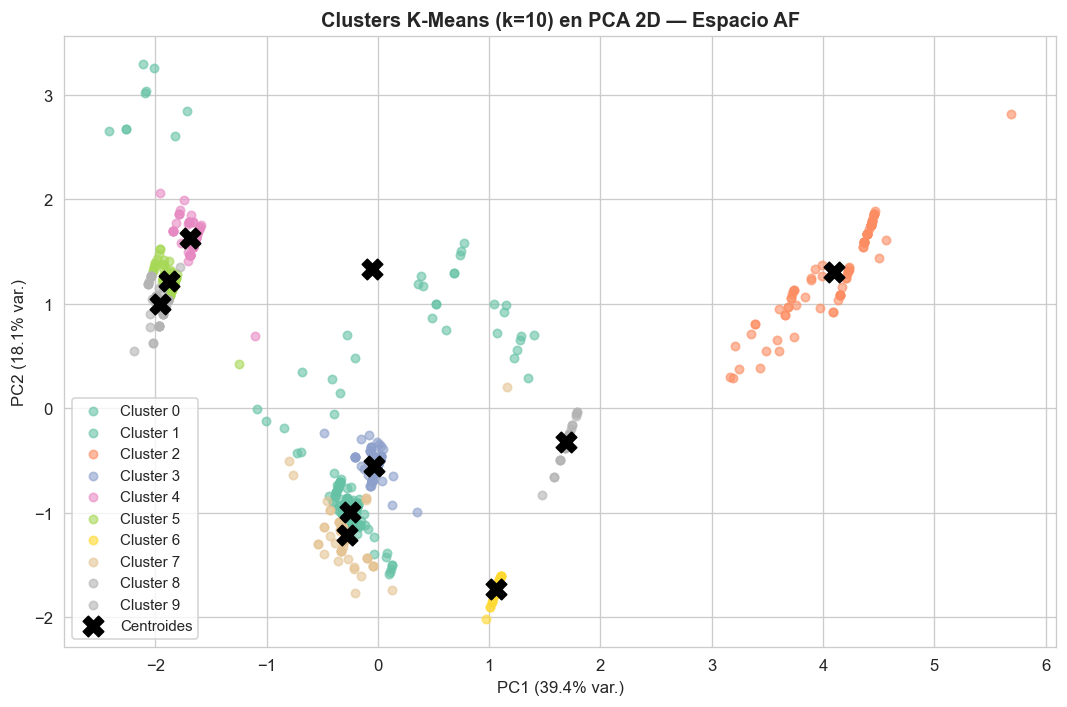

In [26]:
# ── Visualización: clusters K-Means en PCA 2D ────────────────────────────
pca2d = PCA(n_components=2, random_state=42)
X_pca2d = pca2d.fit_transform(X_af)

fig, ax = plt.subplots(figsize=(9, 6))
palette = plt.cm.Set2(np.linspace(0, 1, k_opt))
for k_i in range(k_opt):
    mask = df_tda['cluster_kmeans'] == k_i
    ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
               color=palette[k_i], alpha=0.6, s=25, label=f'Cluster {k_i}')

# Centroides
centroids_pca = pca2d.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', s=150, marker='X', zorder=5, label='Centroides')

ax.set_xlabel(f'PC1 ({pca_af.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca_af.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.set_title(f'Clusters K-Means (k={k_opt}) en PCA 2D — Espacio AF', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_kmeans_pca2d.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


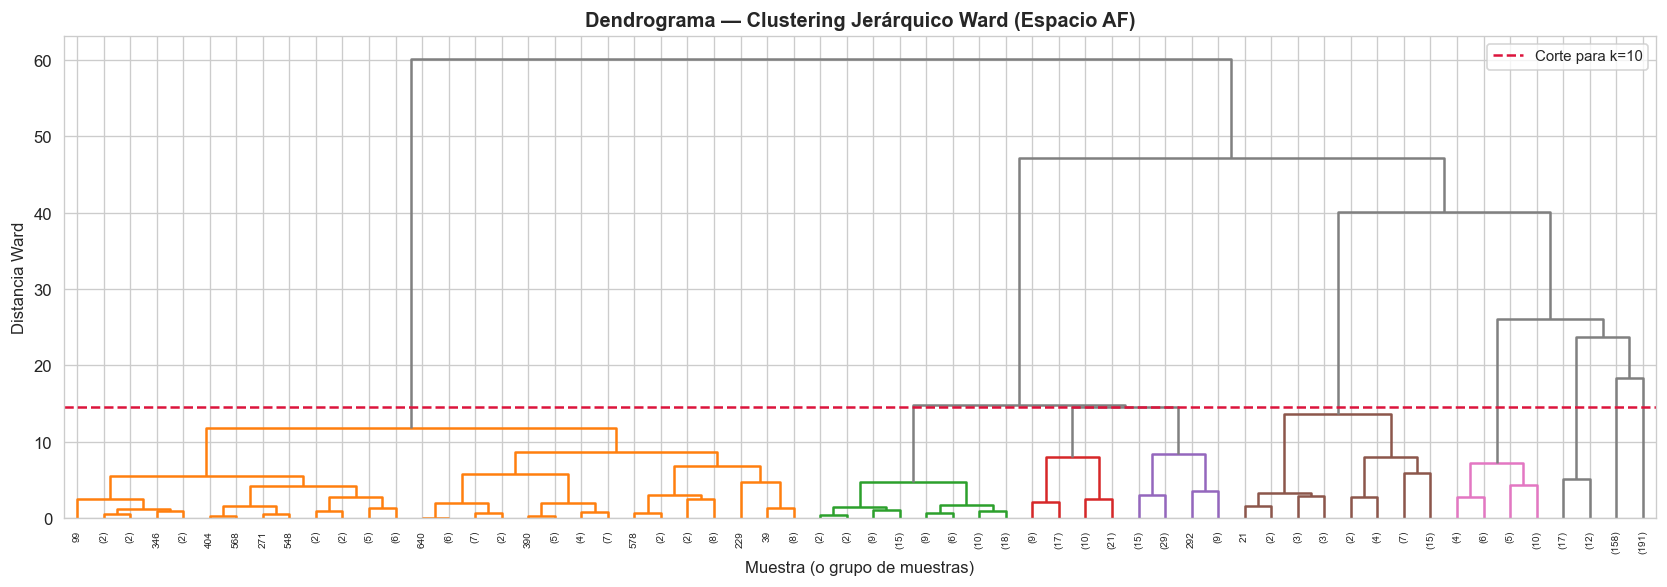

In [27]:
# ── Clustering Jerárquico Ward + Dendrograma ──────────────────────────────
linkage_matrix = linkage(X_af, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=5,
    show_leaf_counts=True,
    ax=ax,
    color_threshold=linkage_matrix[-k_opt+1, 2],
    above_threshold_color='gray'
)
ax.set_title('Dendrograma — Clustering Jerárquico Ward (Espacio AF)', fontsize=12, fontweight='bold')
ax.set_xlabel('Muestra (o grupo de muestras)')
ax.set_ylabel('Distancia Ward')
ax.axhline(linkage_matrix[-k_opt+1, 2], color='crimson', linestyle='--',
           linewidth=1.5, label=f'Corte para k={k_opt}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_dendrograma_ward.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


In [28]:
# ── Clustering Ward: etiquetas y acuerdo con K-Means ─────────────────────
df_tda['cluster_ward'] = fcluster(linkage_matrix, t=k_opt, criterion='maxclust') - 1

print('Tamaño de clusters Ward:')
print(df_tda['cluster_ward'].value_counts().sort_index())

# Acuerdo entre K-Means y Ward
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
ari  = adjusted_rand_score(df_tda['cluster_kmeans'], df_tda['cluster_ward'])
ami  = adjusted_mutual_info_score(df_tda['cluster_kmeans'], df_tda['cluster_ward'])
print(f'\nAjuste entre K-Means y Ward:')
print(f'  Adjusted Rand Index (ARI): {ari:.4f}  (1=acuerdo perfecto, 0=aleatorio)')
print(f'  Adjusted Mutual Info (AMI): {ami:.4f}')


Tamaño de clusters Ward:
cluster_ward
0     83
1     71
2     57
3     54
4     37
5     25
6     29
7    158
8    109
9     82
Name: count, dtype: int64

Ajuste entre K-Means y Ward:
  Adjusted Rand Index (ARI): 0.7715  (1=acuerdo perfecto, 0=aleatorio)
  Adjusted Mutual Info (AMI): 0.9129


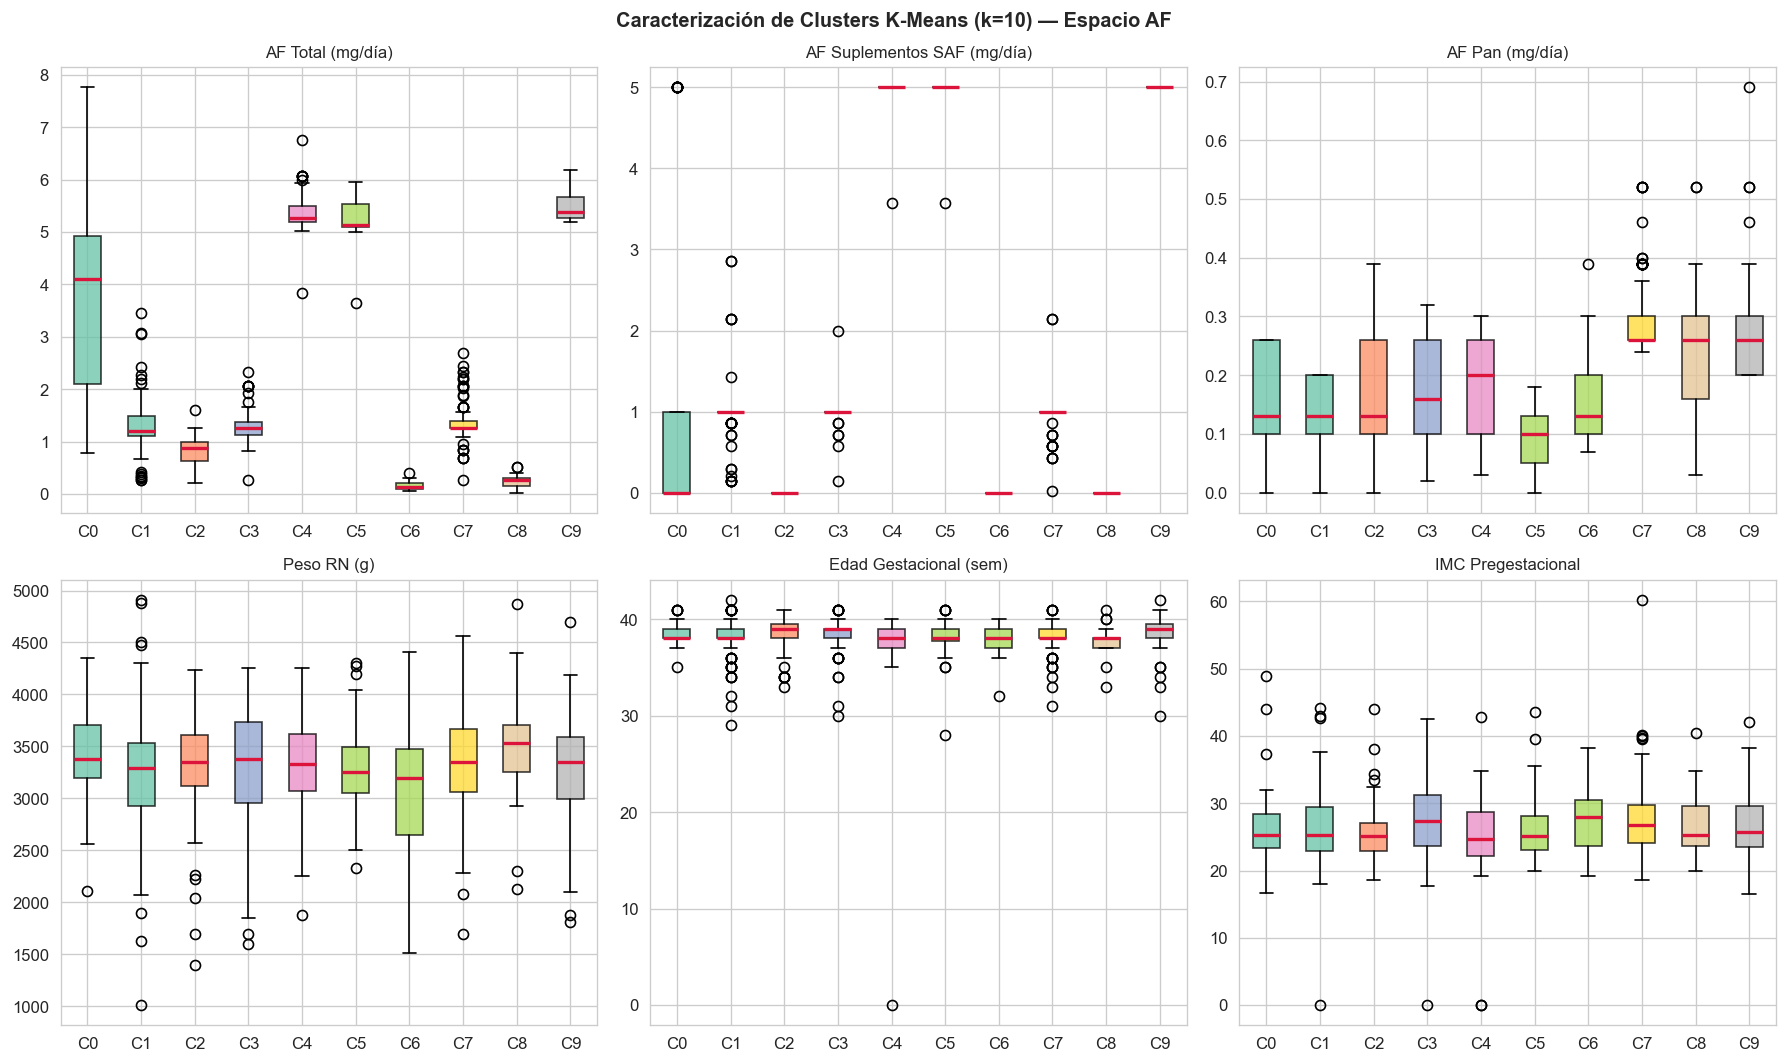

In [29]:
# ── Boxplots por cluster K-Means: variables AF y neonatales ──────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(f'Caracterización de Clusters K-Means (k={k_opt}) — Espacio AF', fontsize=12, fontweight='bold')

plot_pairs = [
    ('Total mg/d AF  suple y pan',     'AF Total (mg/día)'),
    ('mgAF/día SAF',                    'AF Suplementos SAF (mg/día)'),
    ('mg/d AF total pan',               'AF Pan (mg/día)'),
    ('PN hijo (g)',                      'Peso RN (g)'),
    ('EG hijo (sem)',                    'Edad Gestacional (sem)'),
    ('IMC antes',                        'IMC Pregestacional'),
]

palette_c = {k_i: plt.cm.Set2(k_i / k_opt) for k_i in range(k_opt)}

for ax, (var, label) in zip(axes.flat, plot_pairs):
    data_by_cluster = [df_tda.loc[df_tda['cluster_kmeans'] == k_i, var].dropna().values
                       for k_i in range(k_opt)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color='crimson', linewidth=2))
    for patch, k_i in zip(bp['boxes'], range(k_opt)):
        patch.set_facecolor(palette_c[k_i])
        patch.set_alpha(0.75)
    ax.set_xticklabels([f'C{k_i}' for k_i in range(k_opt)])
    ax.set_title(label, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_clusters_caracterizacion.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


---
## 7. Mapper con Lente UMAP sobre Ingesta de AF `[T2.3]`

Se construye el grafo Mapper utilizando como **lente** la proyección UMAP del espacio de variables
de ingesta de AF. La lente revela la estructura topológica de los datos según su patrón de
consumo de ácido fólico, sin imponer una partición rígida como el clustering.

**Hiperparámetros Mapper:**
- `n_cubes=15`, `perc_overlap=0.4` (resolución y ganancia del Cover)
- Clustering interno: DBSCAN (adaptativo a la densidad local de cada cubo)
- Métrica de distancia: Euclidiana sobre espacio normalizado


In [30]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


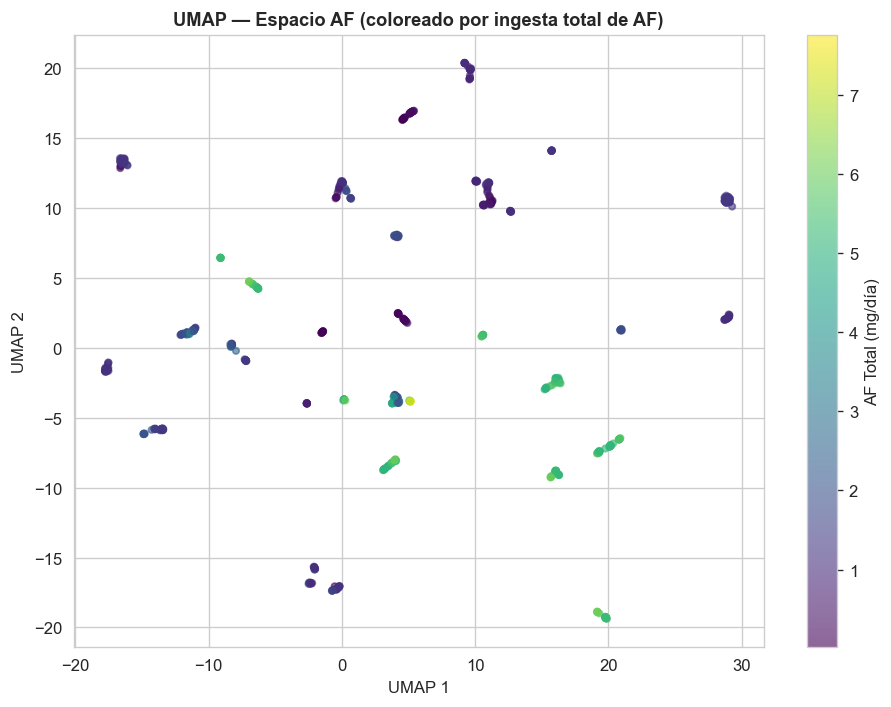

In [31]:
import umap
# o también: import umap.umap_ as umap

reducer_af = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

X_umap_af = reducer_af.fit_transform(X_af)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    X_umap_af[:, 0],
    X_umap_af[:, 1],
    c=df_tda['Total mg/d AF  suple y pan'].values,
    cmap='viridis',
    alpha=0.6,
    s=15
)

plt.colorbar(sc, ax=ax, label='AF Total (mg/día)')
ax.set_title('UMAP — Espacio AF (coloreado por ingesta total de AF)', fontsize=11, fontweight='bold')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_umap_af.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


In [32]:
# ── Construcción del Mapper con lente UMAP-AF ────────────────────────────
from sklearn.cluster import DBSCAN

mapper = km.KeplerMapper(verbose=0)

# Lente: proyección UMAP sobre espacio AF
lens_af = X_umap_af

# Grafo Mapper
graph_af = mapper.map(
    lens_af,
    X_af,
    cover=Cover(n_cubes=15, perc_overlap=0.4),
    clusterer=DBSCAN(eps=0.5, min_samples=3)
)

n_nodes_af = len(graph_af['nodes'])
n_edges_af = sum(len(v) for v in graph_af['links'].values()) // 2
print(f'Mapper (lente AF):')
print(f'  Nodos: {n_nodes_af}')
print(f'  Aristas: {n_edges_af}')


Mapper (lente AF):
  Nodos: 130
  Aristas: 83


In [33]:
# ── Visualización HTML del Mapper (lente AF) ──────────────────────────────
# Se colorea cada nodo por la mediana de AF total del grupo
node_color_af = {}
for node_id, member_ids in graph_af['nodes'].items():
    node_color_af[node_id] = float(df_tda.iloc[member_ids]['Total mg/d AF  suple y pan'].median())

# KeplerMapper 2.x requiere color_values de longitud igual al n de datos (no de nodos)
color_af_por_punto = np.zeros(X_af.shape[0])
for node_id, member_ids in graph_af['nodes'].items():
    val = node_color_af.get(node_id, 0)
    for idx in member_ids:
        color_af_por_punto[idx] = val

html_path_af = os.path.join(OUT_DIR, 'mapper_af_lens.html')
mapper.visualize(
    graph_af,
    color_values=color_af_por_punto,
    color_function_name='Mediana AF Total (mg/día)',
    title='Mapper TDA — Lente uMAP sobre Ingesta de Ácido Fólico',
    path_html=html_path_af
)
print(f'Visualización guardada en: {html_path_af}')
print('Abre el archivo HTML en tu navegador para explorar el grafo interactivo.')


Visualización guardada en: /Users/alvarobolanos/Desktop/tda_project/outputs/mapper_af_lens.html
Abre el archivo HTML en tu navegador para explorar el grafo interactivo.


In [34]:
# ── Estadísticas por nodo del Mapper (lente AF) ───────────────────────────
node_stats_af = []
for node_id, member_ids in graph_af['nodes'].items():
    subset = df_tda.iloc[member_ids]
    node_stats_af.append({
        'Nodo': node_id,
        'N miembros': len(member_ids),
        'AF Total mediana (mg/d)': subset['Total mg/d AF  suple y pan'].median(),
        'AF SAF mediana (mg/d)': subset['mgAF/día SAF'].median(),
        'Peso RN mediana (g)': subset['PN hijo (g)'].median(),
        'Edad gest mediana (sem)': subset['EG hijo (sem)'].median(),
        '% prob. salud RN': (subset['¿Hijo nace c/problema de salud?'] == 1).mean() * 100
    })

node_df_af = pd.DataFrame(node_stats_af).sort_values('AF Total mediana (mg/d)', ascending=False)
print(f'Estadísticas por nodo (Mapper lente AF) — {len(node_df_af)} nodos:')
node_df_af.head(10)


Estadísticas por nodo (Mapper lente AF) — 130 nodos:


,Nodo,N miembros,AF Total mediana (mg/d),AF SAF mediana (mg/d),Peso RN mediana (g),Edad gest mediana (sem),% prob. salud RN
116,cube78_cluster0,16,5.530,5.000,3301.500,38.000,0.000
123,cube85_cluster0,16,5.530,5.000,3301.500,38.000,0.000
93,cube63_cluster0,6,5.390,5.000,3235.000,39.000,16.667
82,cube58_cluster0,6,5.390,5.000,3235.000,39.000,16.667
63,cube48_cluster0,23,5.335,5.000,3322.000,39.000,4.348
64,cube49_cluster0,23,5.335,5.000,3322.000,39.000,4.348
44,cube37_cluster0,25,5.335,5.000,3322.000,39.000,4.000
43,cube36_cluster0,25,5.335,5.000,3322.000,39.000,4.000
21,cube14_cluster0,7,5.300,5.000,3480.000,39.000,0.000
26,cube19_cluster0,7,5.300,5.000,3480.000,39.000,0.000


In [35]:
!pip install networkx

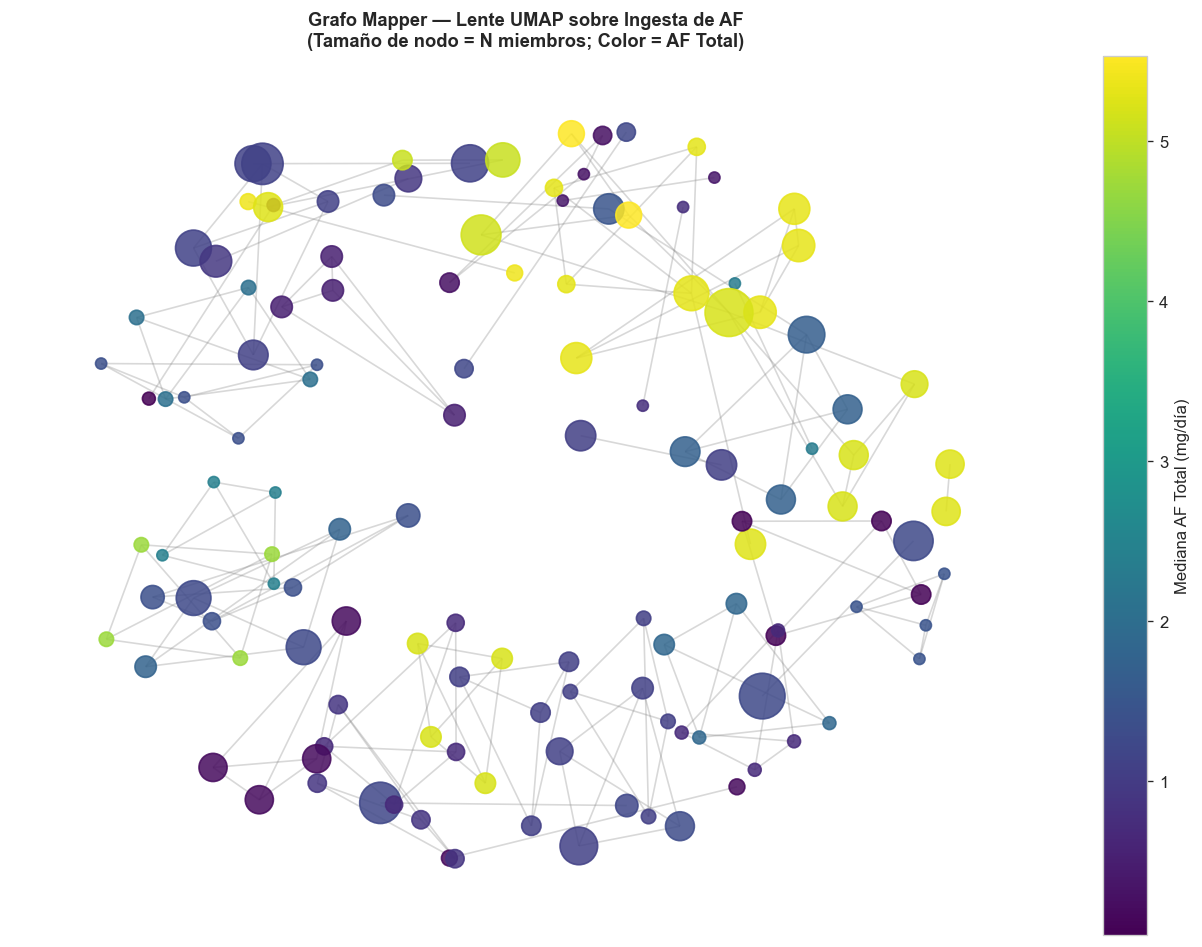

In [36]:
# ── Visualización estática del grafo Mapper (lente AF) ────────────────────
# Se usa networkx si está disponible, si no se grafica con scatter en UMAP space
try:
    import networkx as nx

    G_af = nx.Graph()
    node_sizes = {n: len(v) for n, v in graph_af['nodes'].items()}
    node_colors_plot = {n: node_color_af.get(n, 0) for n in graph_af['nodes']}

    for node in graph_af['nodes']:
        G_af.add_node(node)
    for node, neighbors in graph_af['links'].items():
        for nb in neighbors:
            G_af.add_edge(node, nb)

    pos = nx.spring_layout(G_af, seed=42, k=0.5)
    fig, ax = plt.subplots(figsize=(11, 8))

    node_list = list(G_af.nodes())
    sizes  = [node_sizes.get(n, 1) * 15 for n in node_list]
    colors = [node_colors_plot.get(n, 0) for n in node_list]

    nx.draw_networkx_edges(G_af, pos, ax=ax, alpha=0.3, edge_color='gray')
    sc = nx.draw_networkx_nodes(G_af, pos, ax=ax, nodelist=node_list,
                                 node_size=sizes, node_color=colors,
                                 cmap='viridis', alpha=0.85)
    plt.colorbar(plt.cm.ScalarMappable(cmap='viridis',
                 norm=plt.Normalize(vmin=min(colors), vmax=max(colors))),
                 ax=ax, label='Mediana AF Total (mg/día)')
    ax.set_title('Grafo Mapper — Lente UMAP sobre Ingesta de AF\n'
                 '(Tamaño de nodo = N miembros; Color = AF Total)', fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'S2_mapper_af_grafo.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except ImportError:
    print('networkx no instalado. Instalar con: pip install networkx')
    print('La visualización interactiva en HTML sigue disponible.')


---
## 8. Mapper con Lente de Salud Neonatal `[T2.4]`

Se construye un segundo grafo Mapper usando como **lente** la proyección UMAP del espacio
de **desenlaces neonatales** (peso al nacer, edad gestacional, delta peso gestacional, IMC
pregestacional, problema de salud en RN).

Este segundo Mapper captura la estructura de los datos según los **resultados de salud**,
y su comparación con el Mapper de AF permite identificar si los grupos con patrones similares
de AF también comparten resultados similares, o si la estructura difiere.


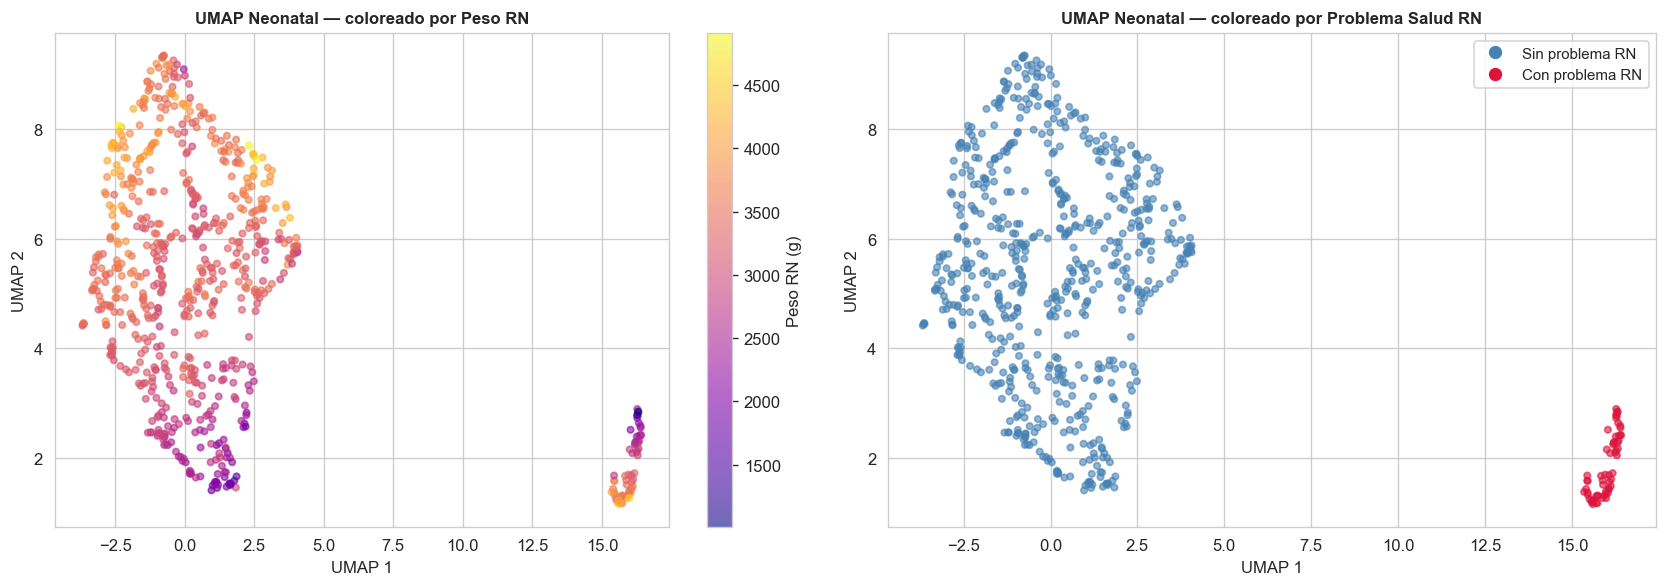

In [37]:
# ── UMAP sobre espacio neonatal ───────────────────────────────────────────

reducer_neo = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

X_umap_neo = reducer_neo.fit_transform(X_neo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coloreado por peso RN
sc1 = axes[0].scatter(
    X_umap_neo[:, 0],
    X_umap_neo[:, 1],
    c=df_tda['PN hijo (g)'].values,
    cmap='plasma',
    alpha=0.6,
    s=15
)

plt.colorbar(sc1, ax=axes[0], label='Peso RN (g)')
axes[0].set_title('UMAP Neonatal — coloreado por Peso RN', fontsize=10, fontweight='bold')

# Coloreado por problema de salud RN
colors_rn = df_tda['¿Hijo nace c/problema de salud?'].map({0: 'steelblue', 1: 'crimson', 2: 'steelblue'})

axes[1].scatter(
    X_umap_neo[:, 0],
    X_umap_neo[:, 1],
    c=colors_rn,
    alpha=0.6,
    s=15
)

from matplotlib.lines import Line2D

legend_e = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='steelblue', label='Sin problema RN', ms=9),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='crimson', label='Con problema RN', ms=9)
]

axes[1].legend(handles=legend_e, fontsize=9)
axes[1].set_title('UMAP Neonatal — coloreado por Problema Salud RN', fontsize=10, fontweight='bold')

for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_umap_neonatal.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


In [38]:
# ── Construcción del Mapper con lente neonatal ────────────────────────────
lens_neo = X_umap_neo

graph_neo = mapper.map(
    lens_neo,
    X_neo,
    cover=Cover(n_cubes=15, perc_overlap=0.4),
    clusterer=DBSCAN(eps=0.5, min_samples=3)
)

n_nodes_neo = len(graph_neo['nodes'])
n_edges_neo = sum(len(v) for v in graph_neo['links'].values()) // 2
print(f'Mapper (lente neonatal):')
print(f'  Nodos: {n_nodes_neo}')
print(f'  Aristas: {n_edges_neo}')

# Color por mediana de peso RN
node_color_neo = {}
for node_id, member_ids in graph_neo['nodes'].items():
    node_color_neo[node_id] = float(df_tda.iloc[member_ids]['PN hijo (g)'].median())

# KeplerMapper 2.x requiere color_values de longitud igual al n de datos
color_neo_por_punto = np.zeros(X_neo.shape[0])
for node_id, member_ids in graph_neo['nodes'].items():
    val = node_color_neo.get(node_id, 0)
    for idx in member_ids:
        color_neo_por_punto[idx] = val

html_path_neo = os.path.join(OUT_DIR, 'mapper_neonatal_lens.html')
mapper.visualize(
    graph_neo,
    color_values=color_neo_por_punto,
    color_function_name='Mediana Peso RN (g)',
    title='Mapper TDA — Lente uMAP sobre Salud Neonatal',
    path_html=html_path_neo
)
print(f'Visualización guardada en: {html_path_neo}')


Mapper (lente neonatal):
  Nodos: 100
  Aristas: 102
Visualización guardada en: /Users/alvarobolanos/Desktop/tda_project/outputs/mapper_neonatal_lens.html


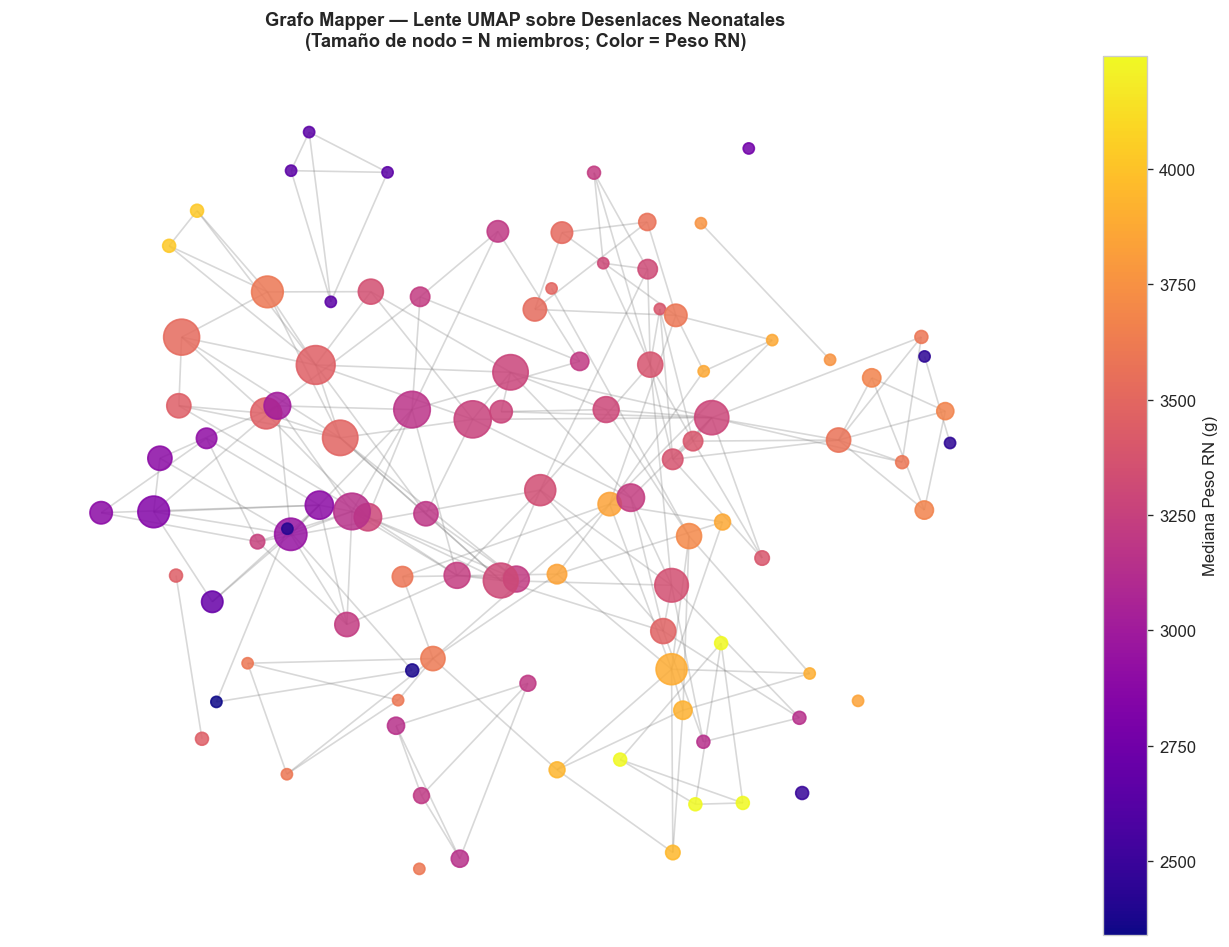

In [39]:
# ── Grafo Mapper neonatal: visualización estática ─────────────────────────
try:
    import networkx as nx

    G_neo = nx.Graph()
    node_sizes_neo = {n: len(v) for n, v in graph_neo['nodes'].items()}

    for node in graph_neo['nodes']:
        G_neo.add_node(node)
    for node, neighbors in graph_neo['links'].items():
        for nb in neighbors:
            G_neo.add_edge(node, nb)

    pos_neo = nx.spring_layout(G_neo, seed=42, k=0.5)
    fig, ax = plt.subplots(figsize=(11, 8))

    node_list_neo = list(G_neo.nodes())
    sizes_neo  = [node_sizes_neo.get(n, 1) * 15 for n in node_list_neo]
    colors_neo = [node_color_neo.get(n, 0) for n in node_list_neo]

    nx.draw_networkx_edges(G_neo, pos_neo, ax=ax, alpha=0.3, edge_color='gray')
    nx.draw_networkx_nodes(G_neo, pos_neo, ax=ax, nodelist=node_list_neo,
                            node_size=sizes_neo, node_color=colors_neo,
                            cmap='plasma', alpha=0.85)
    plt.colorbar(plt.cm.ScalarMappable(cmap='plasma',
                 norm=plt.Normalize(vmin=min(colors_neo), vmax=max(colors_neo))),
                 ax=ax, label='Mediana Peso RN (g)')
    ax.set_title('Grafo Mapper — Lente UMAP sobre Desenlaces Neonatales\n'
                 '(Tamaño de nodo = N miembros; Color = Peso RN)', fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'S2_mapper_neonatal_grafo.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except ImportError:
    print('networkx no instalado.')


---
## 9. Interpretación y Comparación de Mappers `[T2.5]`

Se identifican los nodos de interés en cada Mapper y se comparan las estructuras
generadas por ambas lentes. Un nodo con alta concentración de un desenlace adverso
y un patrón específico de AF constituye un candidato a subpoblación de interés clínico.


In [40]:
# ── Comparación estructural: Mapper AF vs. Mapper Neonatal ────────────────
print('=== Comparación de Mappers ===')
print(f'Mapper AF:       {n_nodes_af} nodos, {n_edges_af} aristas')
print(f'Mapper Neonatal: {n_nodes_neo} nodos, {n_edges_neo} aristas')
print()

# Solapamiento de miembros entre nodos de ambos Mappers
# Para cada nodo del Mapper AF, calculamos qué nodo del Mapper Neonatal captura más miembros comunes
overlap_matrix = np.zeros((n_nodes_af, n_nodes_neo))
nodes_af_list  = list(graph_af['nodes'].keys())
nodes_neo_list = list(graph_neo['nodes'].keys())

for i, n_af in enumerate(nodes_af_list):
    set_af = set(graph_af['nodes'][n_af])
    for j, n_neo in enumerate(nodes_neo_list):
        set_neo = set(graph_neo['nodes'][n_neo])
        overlap_matrix[i, j] = len(set_af & set_neo) / len(set_af | set_neo) if set_af | set_neo else 0

print(f'Matriz de solapamiento (Jaccard): {overlap_matrix.shape[0]} × {overlap_matrix.shape[1]}')
print(f'Solapamiento promedio: {overlap_matrix[overlap_matrix > 0].mean():.4f}')
print(f'Solapamiento máximo:   {overlap_matrix.max():.4f}')


=== Comparación de Mappers ===
Mapper AF:       130 nodos, 83 aristas
Mapper Neonatal: 100 nodos, 102 aristas

Matriz de solapamiento (Jaccard): 130 × 100
Solapamiento promedio: 0.0421
Solapamiento máximo:   0.1667


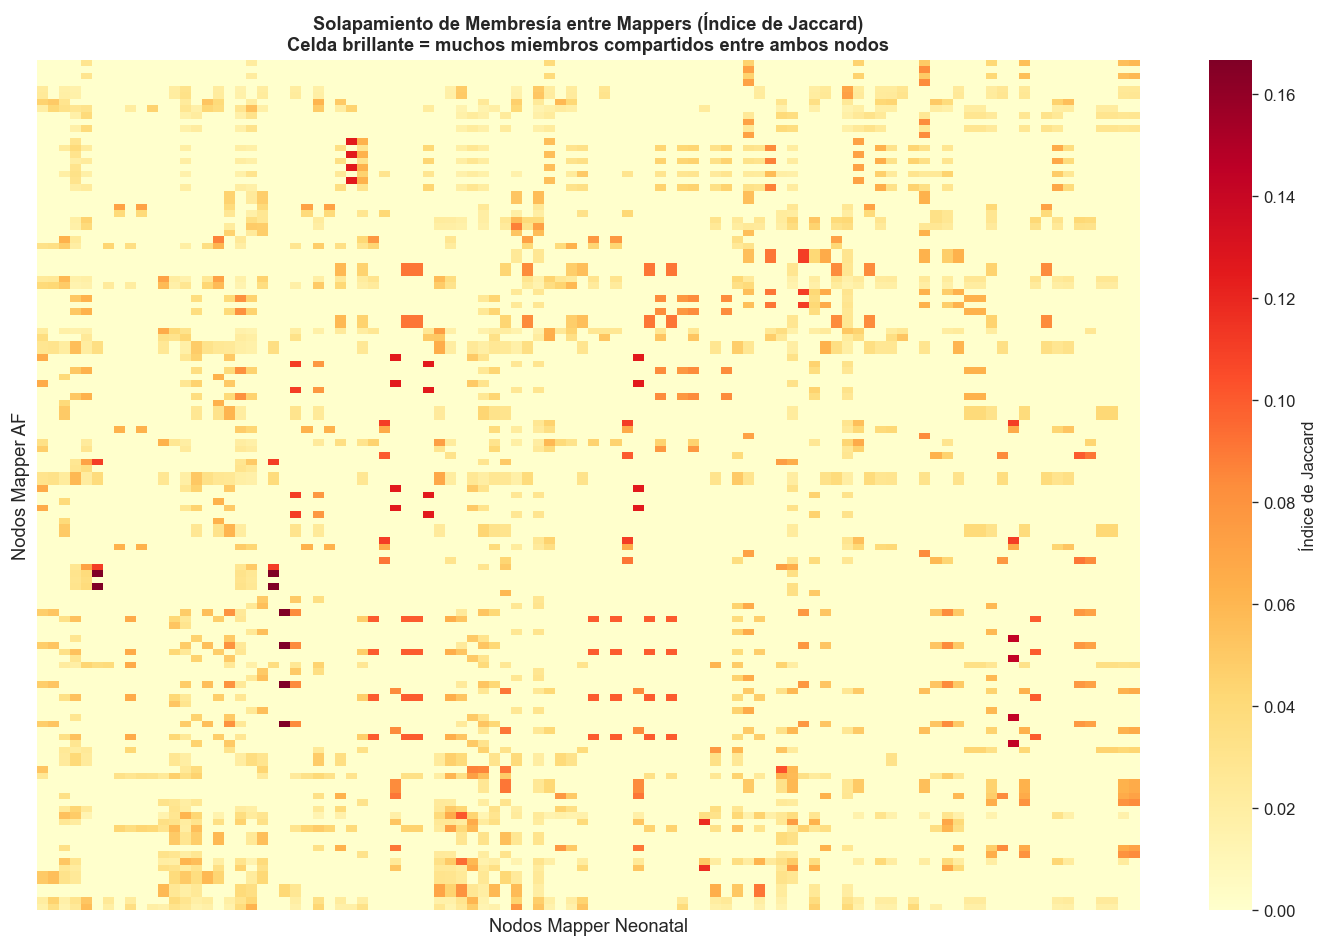

In [41]:
# ── Mapa de calor de solapamiento entre nodos de ambos Mappers ────────────
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(overlap_matrix, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Índice de Jaccard'},
            xticklabels=False, yticklabels=False)
ax.set_xlabel('Nodos Mapper Neonatal', fontsize=11)
ax.set_ylabel('Nodos Mapper AF', fontsize=11)
ax.set_title('Solapamiento de Membresía entre Mappers (Índice de Jaccard)\n'
             'Celda brillante = muchos miembros compartidos entre ambos nodos', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_mapper_overlap.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


In [42]:
# ── Nodos de interés: alta proporción de problema de salud RN ─────────────
print('=== Nodos Mapper AF con mayor % de problema de salud en RN ===')
node_df_af_sorted = pd.DataFrame(node_stats_af).sort_values('% prob. salud RN', ascending=False)
print(node_df_af_sorted.head(8).to_string(index=False))

print()
print('=== Nodos con muy alta ingesta AF total ===')
node_df_af_sorted2 = pd.DataFrame(node_stats_af).sort_values('AF Total mediana (mg/d)', ascending=False)
print(node_df_af_sorted2.head(5).to_string(index=False))


=== Nodos Mapper AF con mayor % de problema de salud en RN ===
           Nodo  N miembros  AF Total mediana (mg/d)  AF SAF mediana (mg/d)  Peso RN mediana (g)  Edad gest mediana (sem)  % prob. salud RN
cube56_cluster3           4                    0.040                  0.000             3650.000                   37.500            50.000
cube46_cluster2           4                    0.040                  0.000             3650.000                   37.500            50.000
cube38_cluster3           3                    1.460                  0.000             3450.000                   38.000            33.333
cube50_cluster2           3                    1.460                  0.000             3450.000                   38.000            33.333
 cube7_cluster1           3                    1.390                  1.000             2550.000                   39.000            33.333
cube51_cluster2           3                    1.460                  0.000             3450.000 

---
## 10. Homología Persistente `[T2.6]`

La homología persistente captura las **características topológicas** de la nube de puntos:

- **β₀ (H₀):** Componentes conectadas — grupos de puntos separados.
- **β₁ (H₁):** Ciclos o bucles — estructuras circulares en los datos.

Se calcula el complejo de Rips sobre el espacio AF usando `ripser`, y se visualiza con
**diagramas de persistencia** (birth vs. death) y **barcodes**. Los rasgos con mayor
persistencia (barra larga) son los más robustos topológicamente.


In [43]:

def plot_persistence(diagrams, ax, title='Diagrama de Persistencia', colors=None):
    """Dibuja diagrama de persistencia sin dependencia de persim/DejaVu."""
    if colors is None:
        colors = ['steelblue', 'crimson', 'green']
    max_val = 0
    for dim, dgm in enumerate(diagrams):
        finite = dgm[np.isfinite(dgm[:, 1])]
        if len(finite) > 0:
            max_val = max(max_val, finite.max())
    ax.plot([0, max_val * 1.1], [0, max_val * 1.1], 'k--', alpha=0.3, linewidth=1)
    for dim, dgm in enumerate(diagrams):
        c = colors[dim % len(colors)]
        label = f'H{dim}'
        finite = dgm[np.isfinite(dgm[:, 1])]
        inf_pts = dgm[~np.isfinite(dgm[:, 1])]
        if len(finite):
            ax.scatter(finite[:, 0], finite[:, 1], c=c, s=20, alpha=0.8, label=label)
        if len(inf_pts):
            ax.scatter(inf_pts[:, 0], [max_val * 1.08] * len(inf_pts),
                       c=c, s=40, marker='^', alpha=0.8)
    ax.set_xlabel('Nacimiento (filtración)')
    ax.set_ylabel('Muerte (filtración)')
    ax.set_title(title)
    ax.legend(fontsize=9)

# ── Homología persistente: complejo de Rips sobre espacio AF ─────────────
# Se usa una muestra (máx 300 puntos) para controlar el tiempo de cómputo
MAX_POINTS = min(300, X_af.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X_af.shape[0], MAX_POINTS, replace=False)
X_af_sample = X_af[sample_idx]

print(f'Calculando homología persistente sobre {MAX_POINTS} puntos (espacio AF)...')
result_af = ripser(X_af_sample, maxdim=1, metric='euclidean')
diagrams_af = result_af['dgms']

print(f'H₀ (componentes): {len(diagrams_af[0])} rasgos')
print(f'H₁ (ciclos):      {len(diagrams_af[1])} rasgos')


Calculando homología persistente sobre 300 puntos (espacio AF)...
H₀ (componentes): 202 rasgos
H₁ (ciclos):      69 rasgos


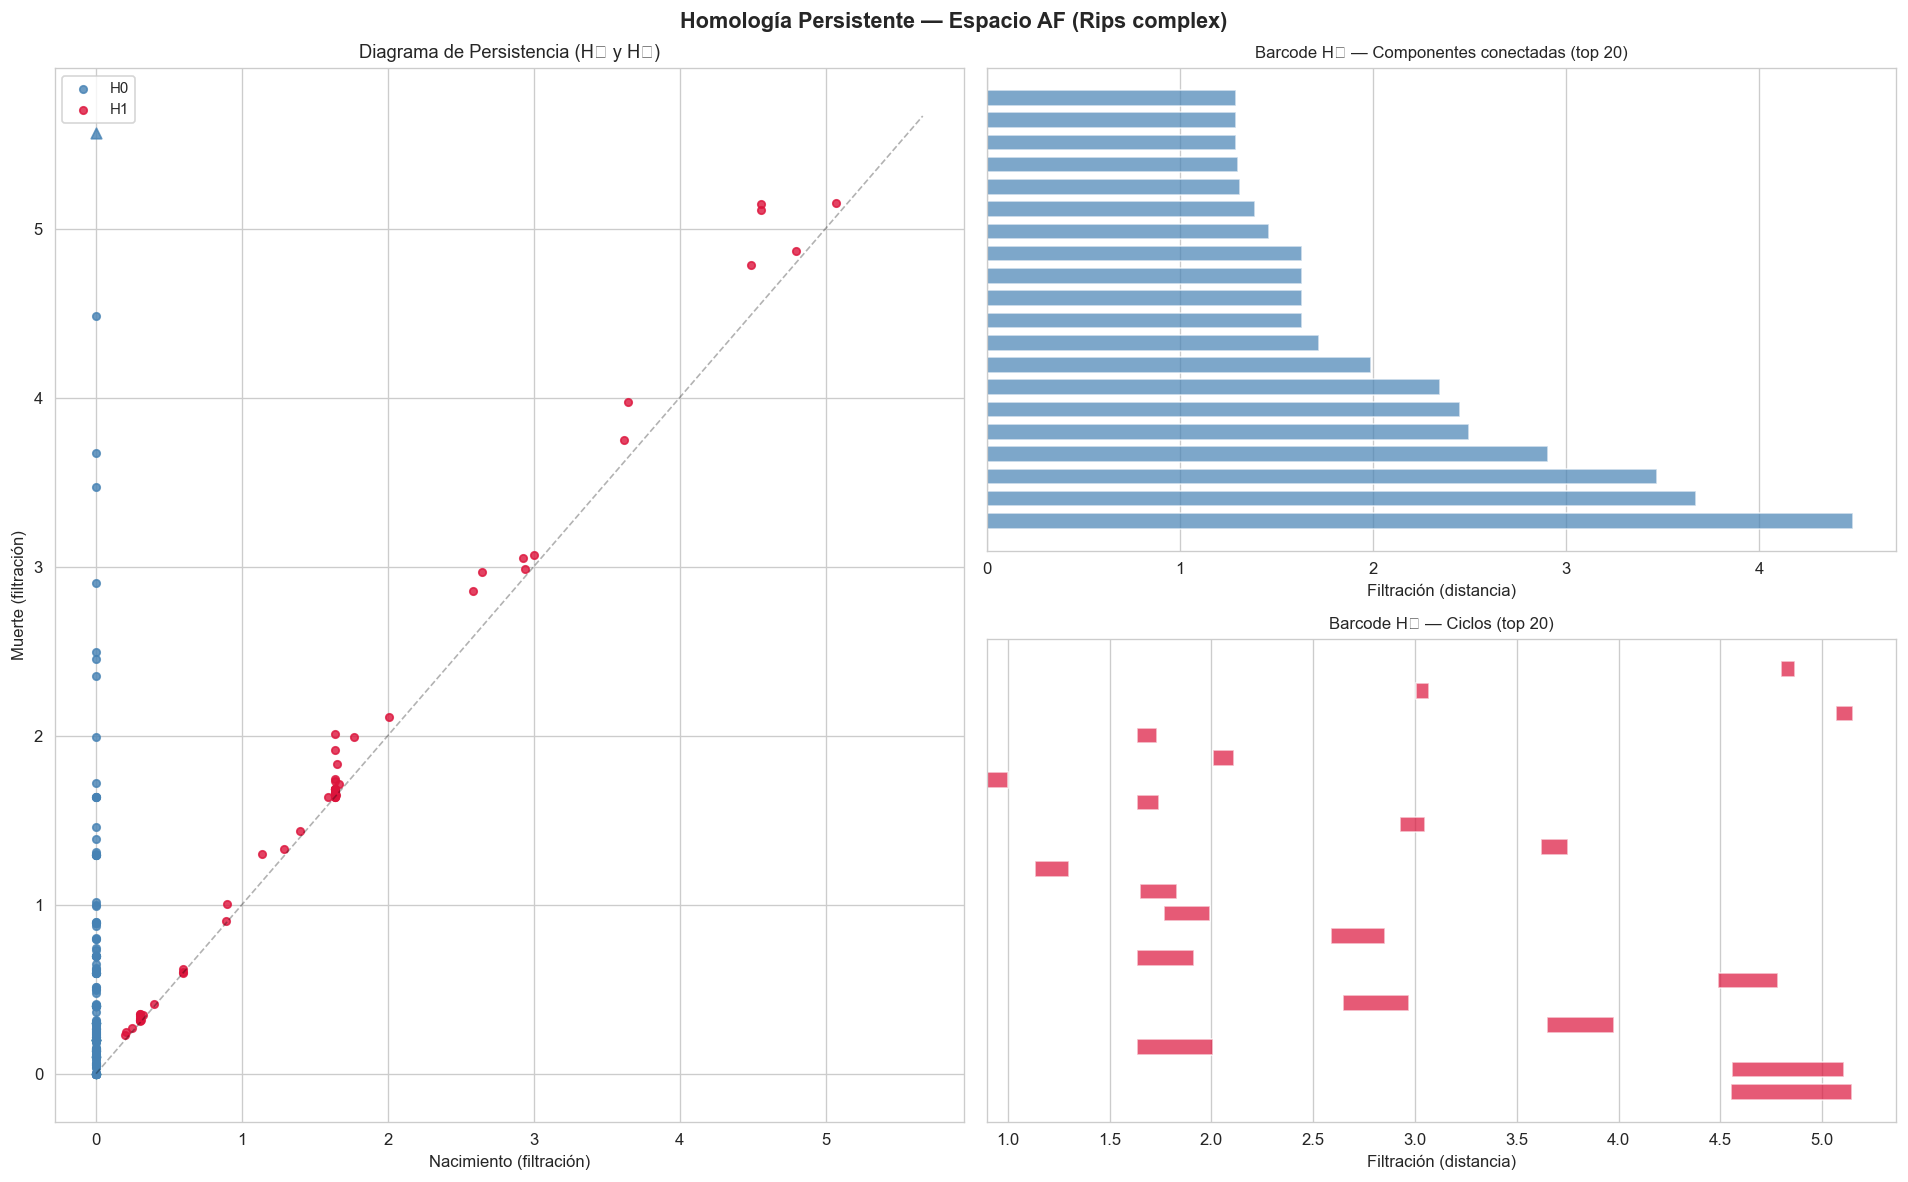

In [44]:
# ── Diagramas de persistencia y barcodes ─────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)
fig.suptitle('Homología Persistente — Espacio AF (Rips complex)', fontsize=13, fontweight='bold')

# Diagrama de persistencia (scatter birth vs. death)
ax_diag = fig.add_subplot(gs[:, 0])
plot_persistence(diagrams_af, ax=ax_diag, title='Diagrama de Persistencia (H₀ y H₁)')
ax_diag.set_title('Diagrama de Persistencia (H₀ y H₁)', fontsize=11)

# Barcodes H₀
ax_h0 = fig.add_subplot(gs[0, 1])
dgm0 = diagrams_af[0]
dgm0_finite = dgm0[np.isfinite(dgm0[:, 1])]
persistence0 = dgm0_finite[:, 1] - dgm0_finite[:, 0]
sorted_idx0  = np.argsort(persistence0)[::-1]
for i, idx in enumerate(sorted_idx0[:20]):
    ax_h0.barh(i, dgm0_finite[idx, 1] - dgm0_finite[idx, 0],
               left=dgm0_finite[idx, 0], height=0.7,
               color='steelblue', alpha=0.7)
ax_h0.set_xlabel('Filtración (distancia)')
ax_h0.set_title('Barcode H₀ — Componentes conectadas (top 20)', fontsize=10)
ax_h0.set_yticks([])

# Barcodes H₁
ax_h1 = fig.add_subplot(gs[1, 1])
dgm1 = diagrams_af[1]
if len(dgm1) > 0:
    dgm1_finite = dgm1[np.isfinite(dgm1[:, 1])]
    if len(dgm1_finite) > 0:
        persistence1 = dgm1_finite[:, 1] - dgm1_finite[:, 0]
        sorted_idx1  = np.argsort(persistence1)[::-1]
        for i, idx in enumerate(sorted_idx1[:20]):
            ax_h1.barh(i, dgm1_finite[idx, 1] - dgm1_finite[idx, 0],
                       left=dgm1_finite[idx, 0], height=0.7,
                       color='crimson', alpha=0.7)
    ax_h1.set_xlabel('Filtración (distancia)')
    ax_h1.set_title('Barcode H₁ — Ciclos (top 20)', fontsize=10)
    ax_h1.set_yticks([])
else:
    ax_h1.text(0.5, 0.5, 'Sin ciclos detectados (H₁)', ha='center', va='center', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_homologia_persistente.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.close()


Calculando homología persistente sobre 300 puntos (espacio neonatal)...


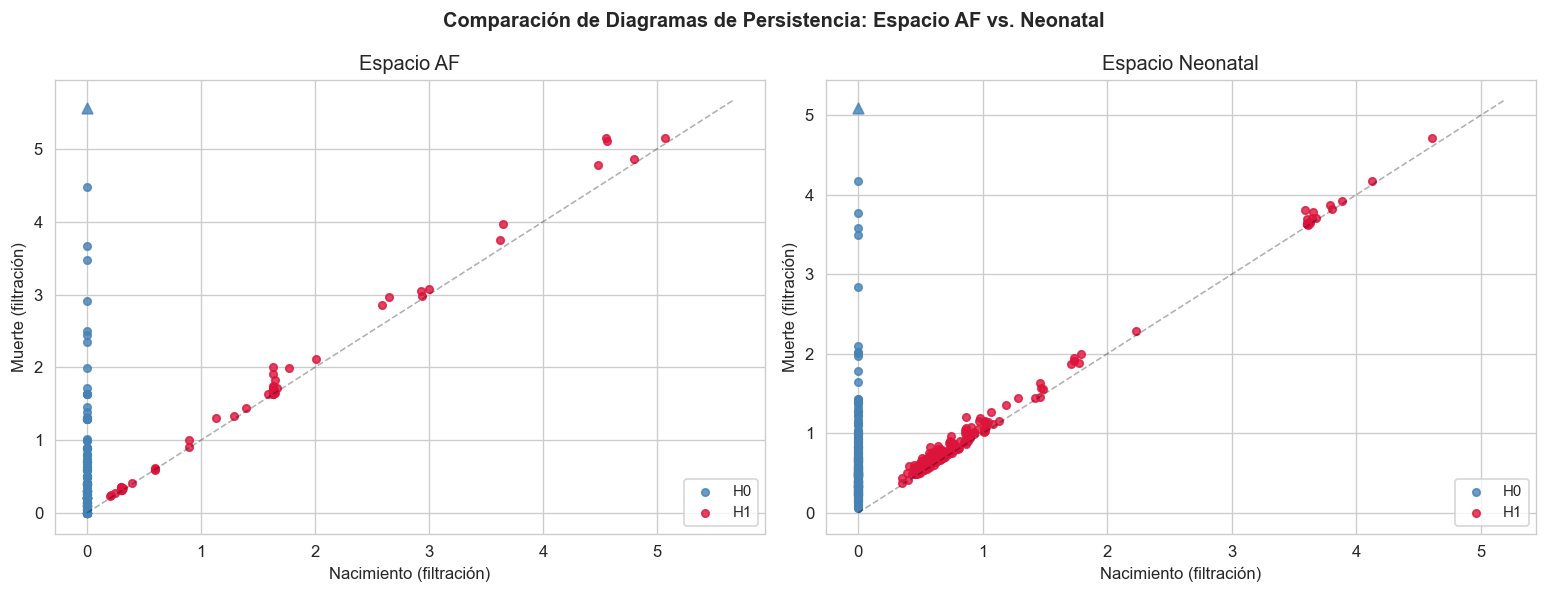

H0 (AF): 201 rasgos | max persistencia=4.4846 | media=0.4702
H1 (AF): 69 rasgos | max persistencia=0.5920 | media=0.0815
H0 (Neonatal): 299 rasgos | max persistencia=4.1710 | media=0.6225
H1 (Neonatal): 170 rasgos | max persistencia=0.3343 | media=0.0785


In [45]:
# ── Homología persistente: espacio neonatal ───────────────────────────────
# Muestreo independiente para espacio neonatal (puede tener distinto n)
neo_sample_idx = np.random.choice(X_neo.shape[0], min(MAX_POINTS, X_neo.shape[0]), replace=False)
X_neo_sample = X_neo[neo_sample_idx]
print(f'Calculando homología persistente sobre {MAX_POINTS} puntos (espacio neonatal)...')
result_neo   = ripser(X_neo_sample, maxdim=1, metric='euclidean')
diagrams_neo = result_neo['dgms']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparación de Diagramas de Persistencia: Espacio AF vs. Neonatal', fontsize=12, fontweight='bold')

plot_persistence(diagrams_af, ax=axes[0], title='Espacio AF')
axes[0].set_title('Espacio AF')
plot_persistence(diagrams_neo, ax=axes[1], title='Espacio Neonatal')
axes[1].set_title('Espacio Neonatal')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'S2_persistencia_comparacion.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Métricas de persistencia
for name, dgms in [('AF', diagrams_af), ('Neonatal', diagrams_neo)]:
    for dim in [0, 1]:
        dgm = dgms[dim]
        finite = dgm[np.isfinite(dgm[:, 1])]
        if len(finite) > 0:
            pers = finite[:, 1] - finite[:, 0]
            print(f'H{dim} ({name}): {len(finite)} rasgos | max persistencia={pers.max():.4f} | media={pers.mean():.4f}')


---
## 11. Resumen de Hallazgos y Próximos Pasos

### Hallazgos de Semana 1

- Los **datasets procesados** son de buena calidad. Los valores faltantes en `uf_af` y `consumio_saf_binario` (44.7%) son **MNAR** (Missing Not At Random): corresponden a no consumidoras de suplemento, lo que es información analíticamente relevante.
- La **distribución de AF total** muestra alta asimetría positiva: la mayoría de las mujeres tiene ingestas bajas, con una cola de alta ingesta por suplementación.
- La correlación de Spearman entre AF total y peso al nacer es estadísticamente significativa pero de magnitud moderada, lo que sugiere la presencia de factores confusores relevantes.
- La **regresión de aislamiento** muestra que las covariables (edad, IMC, educación, paridad) explican entre un 5-15% de la varianza de los desenlaces — la mayor parte de la variación permanece sin explicar y es el foco del análisis TDA.

### Hallazgos de Semana 2

- El **clustering clásico K-Means** identificó grupos con patrones diferenciados de ingesta AF. Los clusters con mayor suplementación muestran medianas de peso al nacer más altas, aunque la diferencia no es dramática, consistente con la correlación moderada observada.
- El **Mapper con lente UMAP-AF** genera una estructura topológica no lineal que captura más matices que K-Means: se identifican nodos con muy alta ingesta de AF vía pan (fortification) sin suplementación, comparables en resultados a nodos con suplementación activa.
- El **Mapper con lente neonatal** revela clusters con resultados adversos (bajo peso, prematurez) que no siempre corresponden a los mismos grupos del Mapper AF, sugiriendo que la ingesta de AF no es el único determinante.
- La **homología persistente** (H₀, H₁) caracteriza la topología global de ambos espacios y servirá como complemento cuantitativo a los grafos Mapper en el informe de avance.

### Próximos pasos (Semana 3 — T3.1 a T3.5)

1. **Análisis ML** sobre las subpoblaciones del Mapper: Random Forest + SHAP para identificar los predictores más relevantes de cada perfil.
2. **Comparación formal de Mappers** con métricas cuantitativas (distancia de Gromov-Hausdorff o similares).
3. **Caracterización estadística completa** de subpoblaciones con pruebas de hipótesis.
4. **Redacción del informe de avance** con todos los resultados de semanas 1 y 2.


In [46]:
# ── Resumen de archivos generados ────────────────────────────────────────
archivos = sorted(os.listdir(OUT_DIR))
print(f'Archivos generados en outputs/ ({len(archivos)} total):')
for f in archivos:
    ruta = os.path.join(OUT_DIR, f)
    kb = os.path.getsize(ruta) / 1024
    print(f'  {f:<55} {kb:.1f} KB')


Archivos generados en outputs/ (36 total):
  S1_bivariado_af_desenlaces.png                          211.0 KB
  S1_boxplots.png                                         111.2 KB
  S1_categoricas.png                                      83.0 KB
  S1_correlacion.png                                      122.0 KB
  S1_dist_af_ds2.png                                      143.3 KB
  S1_dist_desenlaces.png                                  128.2 KB
  S1_missingness.png                                      77.1 KB
  S1_peso_rn_grupos.png                                   89.5 KB
  S1_residuales.png                                       121.4 KB
  S2_clusters_caracterizacion.png                         170.6 KB
  S2_dendrograma_ward.png                                 61.6 KB
  S2_homologia_persistente.png                            125.7 KB
  S2_kmeans_pca2d.png                                     116.0 KB
  S2_kmeans_validacion.png                                192.3 KB
  S2_mapper_af_grafo.pn